# Promotion Impact Analysis on Sales — XYZ E-Commerce

## Problem Statement

The marketing team at XYZ E-commerce, which sells clothing and accessories, wants to know whether promotions have a positive impact on sales.
We, as the data science team, will perform Exploratory Data Analysis (EDA) and build a regression model to study if promotions significantly influence sales.

## Objectives

* To analyze overall sales trends over time.

* To identify top-performing categories and products.

* To compare sales performance with and without promotions.

* To study how time, category, and promotions jointly impact total sales.

* To provide data-driven insights to the marketing team for future promotional planning.

## Dataset Description

The dataset contains order-level sales data from an e-commerce platform (XYZ Company). It includes details such as order information, product category, pricing, quantity, courier status, promotions, and customer location.


* index: Auto-generated index for each record

* Order ID: Unique identifier for each order

* Date: Date when the order was placed

* Status: Order processing status (e.g., Shipped, Cancelled, Delivered)

* Fulfilment: Indicates who fulfilled the order — Amazon or Merchant

* Sales Channel: Platform through which the sale occurred (e.g., Amazon.in)

* ship-service-level: Shipping method chosen for the order (e.g., Standard, Expedited)

* Style: Product style code or identifier

* SKU: Stock Keeping Unit — unique product identifier

* Category: Product category (e.g., Kurta, Set, Saree)

* Size: Product size (e.g., S, M, XL, 3XL)

* ASIN: Amazon Standard Identification Number (unique item code)

* Courier Status: Current shipping/courier delivery status

* Qty: Quantity of items sold in the order

* currency: Currency in which the sale was made (mostly INR)

* Amount: Net order value (sales amount)

* ship-city: Destination city of the order

* ship-state: Destination state of the order

* ship-postal-code: Destination postal code

* ship-country: Destination country of the order

* promotion-ids: Promotion identifiers applied to the order

* B2B: Boolean flag indicating whether the order is business-to-business

* fulfilled-by: Indicates who fulfilled the shipment (e.g., Easy Ship, Amazon)

* Unnamed: 22: Miscellaneous information (may contain null or irrelevant data)

## Importing Libraries and Loading the Dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from warnings import filterwarnings
filterwarnings('ignore')

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

plt.rcParams['figure.figsize'] = [15, 10]
plt.rcParams['font.size'] = 14
plt.rcParams['axes.grid'] = False

In [ ]:
data = pd.read_csv('Amazon Sale Report.csv')
df = data.copy()
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,NaN,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,NaN,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [ ]:
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')

Rows: 128975, Columns: 24


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

## Data Cleaning and Preprocessing

In [ ]:
# Row and Columns wise null value percentages
(df.isnull().sum().sum() / df.size) * 100

np.float64(6.800251986819152)

In [ ]:
(df.isnull().sum() / df.shape[0]) * 100

index                  0.000000
Order ID               0.000000
Date                   0.000000
Status                 0.000000
Fulfilment             0.000000
Sales Channel          0.000000
ship-service-level     0.000000
Style                  0.000000
SKU                    0.000000
Category               0.000000
Size                   0.000000
ASIN                   0.000000
Courier Status         5.328164
Qty                    0.000000
currency               6.043807
Amount                 6.043807
ship-city              0.025586
ship-state             0.025586
ship-postal-code       0.025586
ship-country           0.025586
promotion-ids         38.110487
B2B                    0.000000
fulfilled-by          69.546811
Unnamed: 22           38.030626
dtype: float64

In [ ]:
df[ df.duplicated() ]

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22


In [ ]:
# Dropping unwanted columns
df.drop(columns = ['Unnamed: 22','ship-postal-code','ship-country','index','Order ID','fulfilled-by'], axis=1, inplace=True)

In [ ]:
num = df.select_dtypes(include=np.number).columns.to_list()
cat = df.select_dtypes(include='object').columns.to_list()
boolean = df.select_dtypes(include='bool').columns.to_list()

In [ ]:
num

['Qty', 'Amount']

In [ ]:
boolean

['B2B']

In [ ]:
cat

['Date',
 'Status',
 'Fulfilment',
 'Sales Channel ',
 'ship-service-level',
 'Style',
 'SKU',
 'Category',
 'Size',
 'ASIN',
 'Courier Status',
 'currency',
 'ship-city',
 'ship-state',
 'promotion-ids']

In [ ]:
for i in cat:
    print(i)
    print(df[i].unique())
    print('----------------------')

Date
['04-30-22' '04-29-22' '04-28-22' '04-27-22' '04-26-22' '04-25-22'
 '04-24-22' '04-23-22' '04-22-22' '04-21-22' '04-20-22' '04-19-22'
 '04-18-22' '04-17-22' '04-16-22' '04-15-22' '04-14-22' '04-13-22'
 '04-12-22' '04-11-22' '04-10-22' '04-09-22' '04-08-22' '04-07-22'
 '04-06-22' '04-05-22' '04-04-22' '04-03-22' '04-02-22' '04-01-22'
 '03-31-22' '05-31-22' '05-30-22' '05-29-22' '05-28-22' '05-27-22'
 '05-26-22' '05-25-22' '05-24-22' '05-23-22' '05-22-22' '05-21-22'
 '05-20-22' '05-19-22' '05-18-22' '05-17-22' '05-16-22' '05-15-22'
 '05-14-22' '05-13-22' '05-12-22' '05-11-22' '05-10-22' '05-09-22'
 '05-08-22' '05-07-22' '05-06-22' '05-05-22' '05-04-22' '05-03-22'
 '05-02-22' '05-01-22' '06-29-22' '06-28-22' '06-27-22' '06-26-22'
 '06-25-22' '06-24-22' '06-23-22' '06-22-22' '06-21-22' '06-20-22'
 '06-19-22' '06-18-22' '06-17-22' '06-16-22' '06-15-22' '06-14-22'
 '06-13-22' '06-12-22' '06-11-22' '06-10-22' '06-09-22' '06-08-22'
 '06-07-22' '06-06-22' '06-05-22' '06-04-22' '06-03-22' '

In [ ]:
for i in num:
    print(i)
    print(df[i].agg([min, max]))
    print('-----------------------------')

Qty
min     0
max    15
Name: Qty, dtype: int64
-----------------------------
Amount
min       0.0
max    5584.0
Name: Amount, dtype: float64
-----------------------------


In [ ]:
df.shape

(128975, 18)

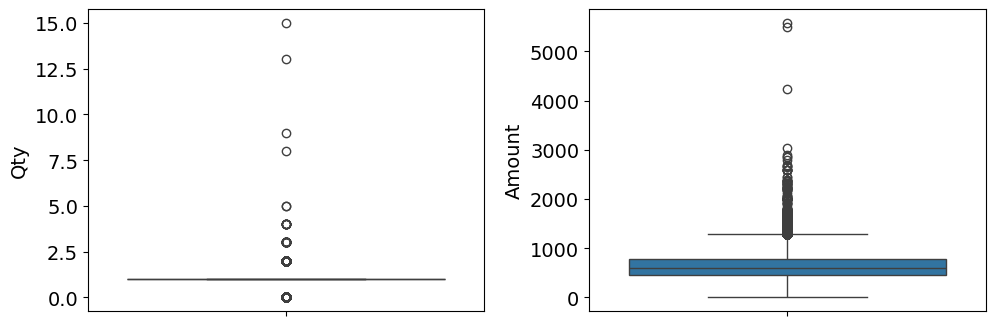

In [ ]:
t = 1

for i in num:
    plt.subplot(3, 3, t)

    sns.boxplot(df[i])

    t += 1

plt.tight_layout()
plt.show()

In [ ]:
for i in num:
    df[i] = np.log1p(df[i])

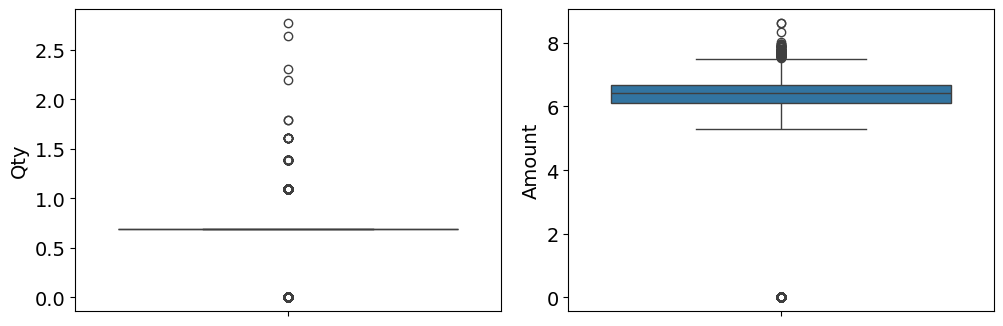

In [ ]:
t = 1

for i in num:
    plt.subplot(3, 3, t)

    sns.boxplot(df[i])

    t += 1

plt.tight_layout()
plt.show()

In [ ]:
# Checking null values after dropping columns
( df.isnull().sum().sum() / df.size) * 100

np.float64(3.087635415993625)

In [ ]:
( df.isnull().sum() / df.shape[0]) * 100

Date                   0.000000
Status                 0.000000
Fulfilment             0.000000
Sales Channel          0.000000
ship-service-level     0.000000
Style                  0.000000
SKU                    0.000000
Category               0.000000
Size                   0.000000
ASIN                   0.000000
Courier Status         5.328164
Qty                    0.000000
currency               6.043807
Amount                 6.043807
ship-city              0.025586
ship-state             0.025586
promotion-ids         38.110487
B2B                    0.000000
dtype: float64

In [ ]:
df['Courier Status'].unique()

array([nan, 'Shipped', 'Cancelled', 'Unshipped'], dtype=object)

In [ ]:

df[
     df['Courier Status'].isnull() &
     df['Status'].isin(['Cancelled','Shipped - Delivered to Buyer','Shipped - Returned to Seller'])
  ].head()

,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,promotion-ids,B2B
0,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,NaN,0.0,INR,6.474847,MUMBAI,MAHARASHTRA,NaN,False
3,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,NaN,0.0,INR,6.625830,PUDUCHERRY,PUDUCHERRY,NaN,False
23,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET291,SET291-KR-PP-M,Set,M,B099NK55YG,NaN,0.0,INR,6.348229,pune,MAHARASHTRA,NaN,False
29,04-30-22,Cancelled,Merchant,Amazon.in,Standard,JNE2132,JNE2132-KR-398-XXXL,kurta,3XL,B07JG3CND8,NaN,0.0,NaN,NaN,GUWAHATI,ASSAM,NaN,False
83,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET377,SET377-KR-NP-M,Set,M,B09TZV23QS,NaN,0.0,INR,7.008831,DEHRADUN,UTTARAKHAND,NaN,False


In [ ]:
# In our data, if user has paid any amount then currency is INR else NaN. Now let us treat currency and amount
# if currency is nan, then treat with INR, if amount is NaN, then treat with 0.00

In [ ]:
df['currency'] = df['currency'].fillna('INR')
df['Amount'] = df['Amount'].fillna(0)

In [ ]:
# When promotion id is NaN, the we can treat the null values with 'Promotion Not applied'
# By same way, we should give ship city not given and ship state not given.

In [ ]:
df['promotion-ids'] = df['promotion-ids'].fillna('Promotion Not applied')
df['ship-city'] = df['ship-city'].fillna('Shipping City Not Given')
df['ship-state'] = df['ship-state'].fillna('Shipping State Not Given')

In [ ]:
df.loc[(df['Courier Status'].isnull()) & (df['Status'] == 'Cancelled'), 'Courier Status'] = 'Cancelled'
df.loc[(df['Courier Status'].isnull()) & (df['Status'] == 'Shipped - Delivered to Buyer'), 'Courier Status'] = 'Shipped'
df.loc[(df['Courier Status'].isnull()) & (df['Status'] == 'Shipped - Returned to Seller'), 'Courier Status'] = 'Shipped'

In [ ]:
(df.isnull().sum() / df.shape[0]) *100

Date                  0.0
Status                0.0
Fulfilment            0.0
Sales Channel         0.0
ship-service-level    0.0
Style                 0.0
SKU                   0.0
Category              0.0
Size                  0.0
ASIN                  0.0
Courier Status        0.0
Qty                   0.0
currency              0.0
Amount                0.0
ship-city             0.0
ship-state            0.0
promotion-ids         0.0
B2B                   0.0
dtype: float64

## Univariate Analysis

In [ ]:
def suggest_eda_methods(df):
    import pandas as pd

    # Identify column types
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    date_cols = df.select_dtypes(include=['datetime64']).columns.tolist()

    print("===== UNIVARIATE ANALYSIS =====")
    print("\nFor Numerical Columns:")
    print("   - Descriptive statistics: mean(), median(), mode(), std(), var(), min(), max()")
    print("   - Distribution plots: hist(), kdeplot(), boxplot()")
    print("   - Columns:", numeric_cols)

    print("\nFor Categorical Columns:")
    print("   - Frequency counts: value_counts()")
    print("   - Bar plots or pie charts")
    print("   - Columns:", categorical_cols)

    if date_cols:
        print("\nFor Date/Time Columns:")
        print("   - Time trend plots (line plots)")
        print("   - Columns:", date_cols)

    print("\n\n===== BIVARIATE ANALYSIS =====")
    print("\nNumerical vs Numerical:")
    print("   - Scatter plot, correlation matrix, pairplot")
    print("   - Examples: ", [(x, y) for i, x in enumerate(numeric_cols) for y in numeric_cols[i+1:]])

    print("\nNumerical vs Categorical:")
    print("   - Boxplot, violin plot, groupby mean(), bar chart")
    print("   - Examples: ", [(cat, num) for cat in categorical_cols for num in numeric_cols])

    print("\nCategorical vs Categorical:")
    print("   - Crosstab, stacked bar chart, heatmap of counts")
    print("   - Examples: ", [(x, y) for i, x in enumerate(categorical_cols) for y in categorical_cols[i+1:]])

    if date_cols:
        print("\nTime Series Bivariate:")
        print("   - Date vs Amount, Date vs Quantity for trends")

    print("\n\n===== MULTIVARIATE ANALYSIS =====")
    print("\nNumerical + Categorical:")
    print("   - Grouped bar charts, pivot tables, heatmaps")
    print("   - Example: Category × State × Amount")

    print("\nNumerical + Numerical + Categorical:")
    print("   - 3D plots, hue-based scatterplots (e.g., sns.scatterplot with hue)")
    print("   - Example: Amount × Qty × Status")

    print("\nDimensionality Reduction:")
    print("   - PCA (Principal Component Analysis) for numerical data")
    print("   - LDA (Linear Discriminant Analysis) for labeled data")

    print("\nCorrelation & Multicollinearity Check:")
    print("   - Heatmap of df.corr(), VIF analysis (Variance Inflation Factor)")

    print("\nYou can combine any 3+ columns for multivariate analysis.")
    print("\nExample: ['Amount', 'Qty', 'Category'], ['Amount', 'ship-state', 'Status']\n")

# Example usage:
# suggest_eda_methods(df)


In [ ]:
suggest_eda_methods(df)

📊 ===== UNIVARIATE ANALYSIS =====

👉 For Numerical Columns:
   - Descriptive statistics: mean(), median(), mode(), std(), var(), min(), max()
   - Distribution plots: hist(), kdeplot(), boxplot()
   - Columns: ['Qty', 'Amount']

👉 For Categorical Columns:
   - Frequency counts: value_counts()
   - Bar plots or pie charts
   - Columns: ['Date', 'Status', 'Fulfilment', 'Sales Channel ', 'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN', 'Courier Status', 'currency', 'ship-city', 'ship-state', 'promotion-ids', 'B2B']


📈 ===== BIVARIATE ANALYSIS =====

👉 Numerical vs Numerical:
   - Scatter plot, correlation matrix, pairplot
   - Examples:  [('Qty', 'Amount')]

👉 Numerical vs Categorical:
   - Boxplot, violin plot, groupby mean(), bar chart
   - Examples:  [('Date', 'Qty'), ('Date', 'Amount'), ('Status', 'Qty'), ('Status', 'Amount'), ('Fulfilment', 'Qty'), ('Fulfilment', 'Amount'), ('Sales Channel ', 'Qty'), ('Sales Channel ', 'Amount'), ('ship-service-level', 'Qty'), ('shi

In [ ]:
df[num].describe()

,Qty,Amount
count,128975.000000,128975.000000
mean,0.625699,5.914945
std,0.209502,1.767350
min,0.000000,0.000000
25%,0.693147,6.025866
50%,0.693147,6.369901
75%,0.693147,6.648985
max,2.772589,8.627840


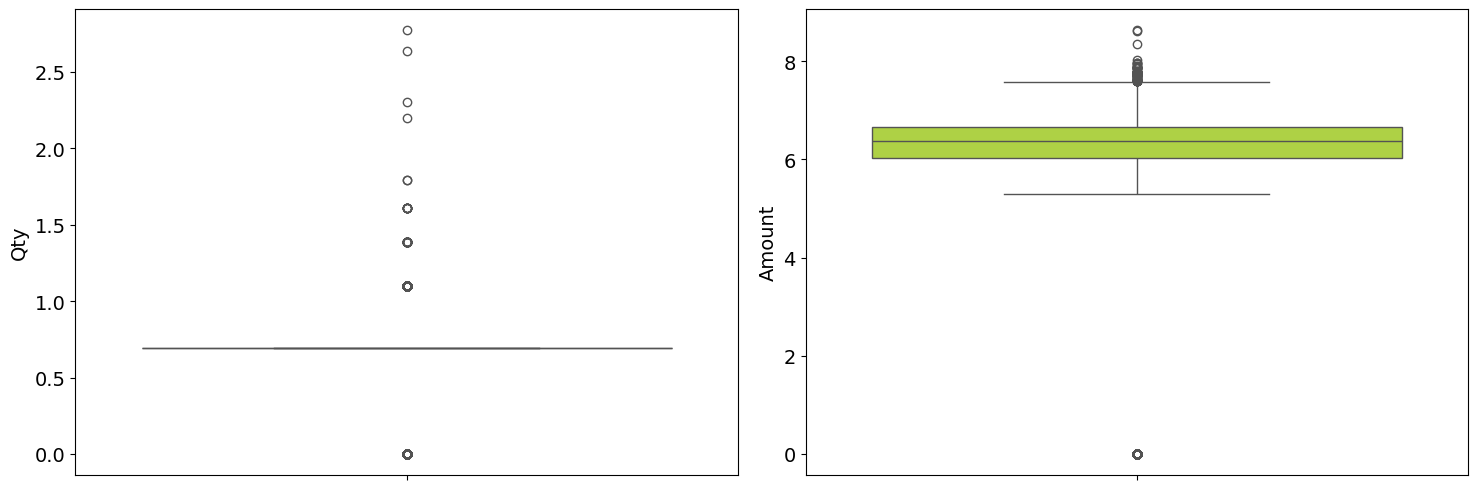

In [ ]:
t = 1

for i in num:
    plt.subplot(2,2,t)

    sns.boxplot(df[i], color='#bae82e')

    t += 1

plt.tight_layout()
plt.show()

#### 🧾 Numerical Features
- **Amount** and **Qty** show a right-skewed distribution — most orders have lower sales values, while a few large orders contribute to the high tail.
- The **Quantity (Qty)** variable typically peaks at smaller values (1–3), indicating that customers mostly purchase single items per order.
- The **Amount** variable has some outliers, possibly representing bulk orders or premium products.

In [ ]:
cat

['Date',
 'Status',
 'Fulfilment',
 'Sales Channel ',
 'ship-service-level',
 'Style',
 'SKU',
 'Category',
 'Size',
 'ASIN',
 'Courier Status',
 'currency',
 'ship-city',
 'ship-state',
 'promotion-ids']

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df['Date'][0:5]

0   2022-04-30
1   2022-04-30
2   2022-04-30
3   2022-04-30
4   2022-04-30
Name: Date, dtype: datetime64[ns]

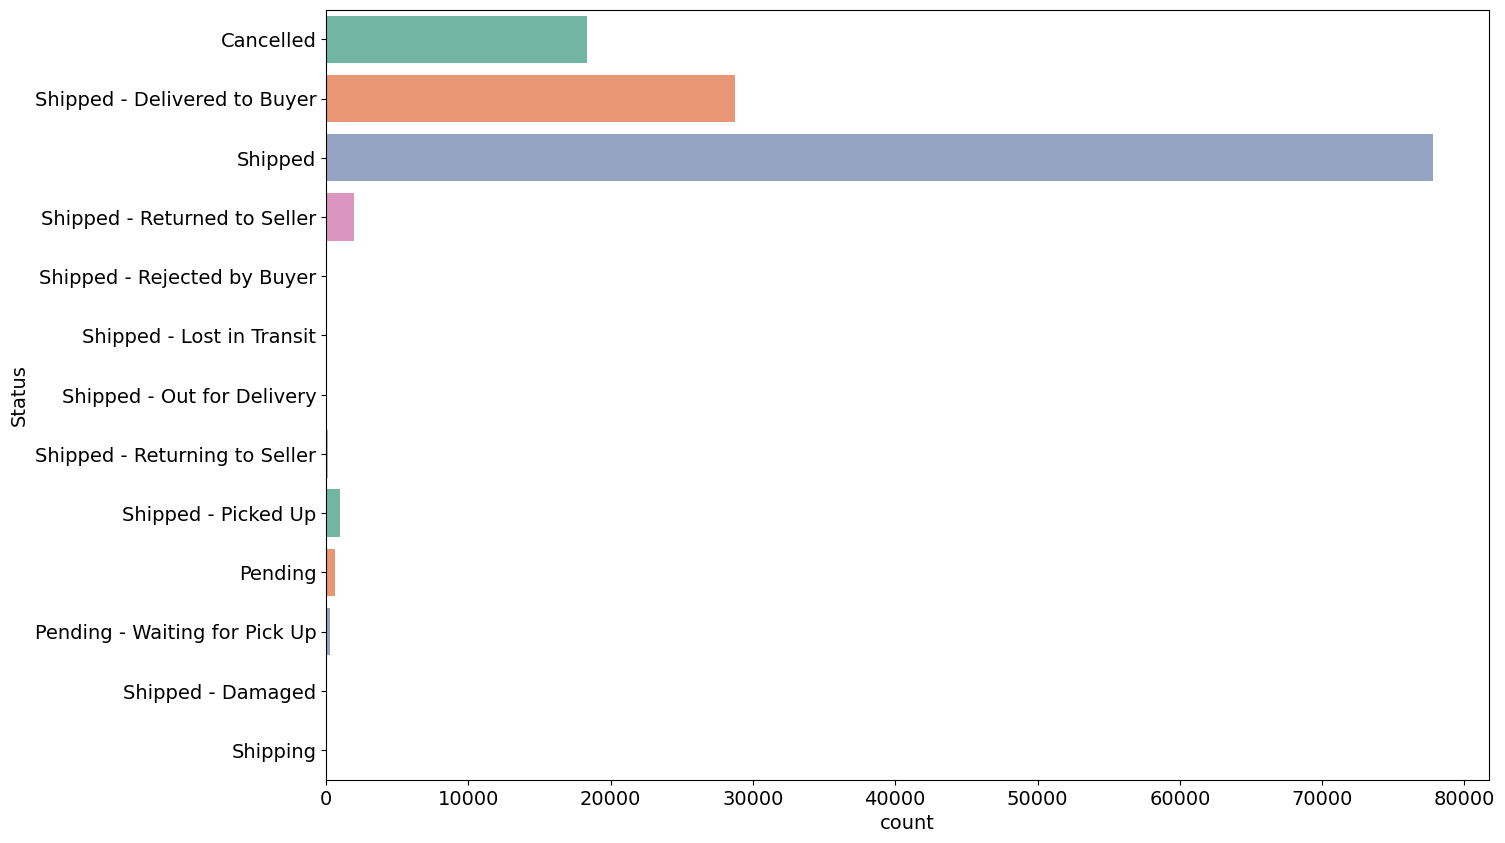

In [ ]:
sns.countplot(df['Status'], palette='Set2')
plt.show()

📦 Order Status Insights

* Over 75,000 orders have been shipped, making it the most frequent status on the chart.
* The next highest category is shipped and delivered to buyer, accounting for approximately 30,000 orders.
* Order cancellations rank third in volume, trailing behind the other two statuses.

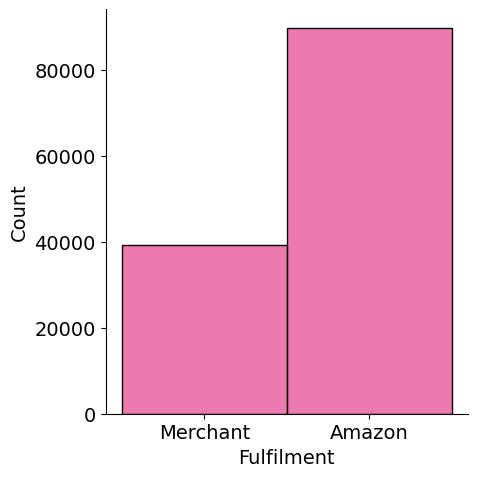

In [ ]:
sns.displot(df['Fulfilment'], color='#e84d95')
plt.show()

Sales Channel Comparison:
* Amazon holds a clear advantage, with the highest number of orders compared to the merchant channel.
* The data shows a significant lead, highlighting Amazon's dominant position in order volume.

In [ ]:
df['Sales Channel '].value_counts()

Sales Channel 
Amazon.in     128851
Non-Amazon       124
Name: count, dtype: int64

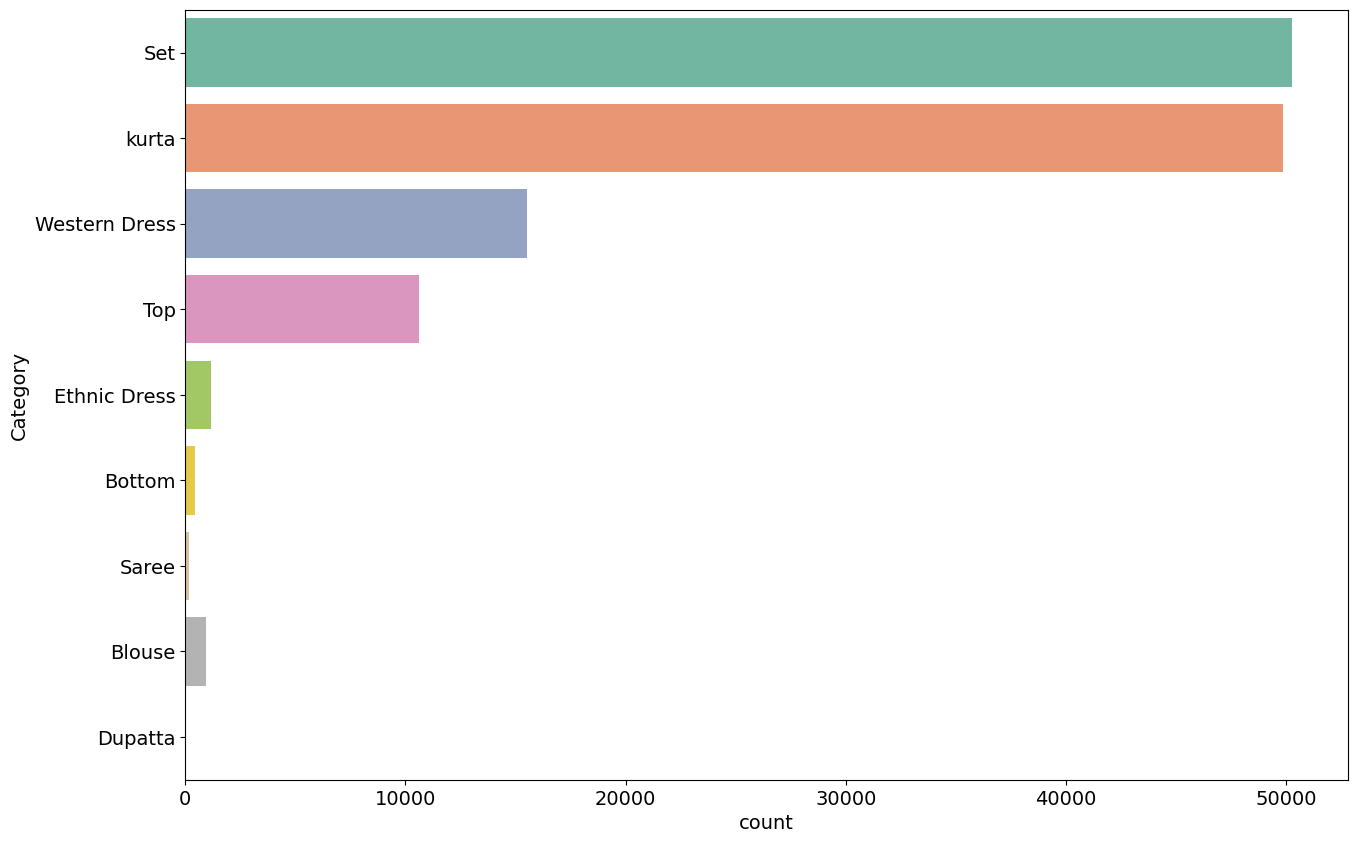

In [ ]:
sns.countplot(df['Category'], palette = 'Set2')
plt.show()

Top Performing Categories by Order Volume:

* Set leads as the most ordered category, securing the top position.
* Kurta ranks second, reflecting strong demand.
* Western Dress holds the third spot, showing notable popularity among buyers.


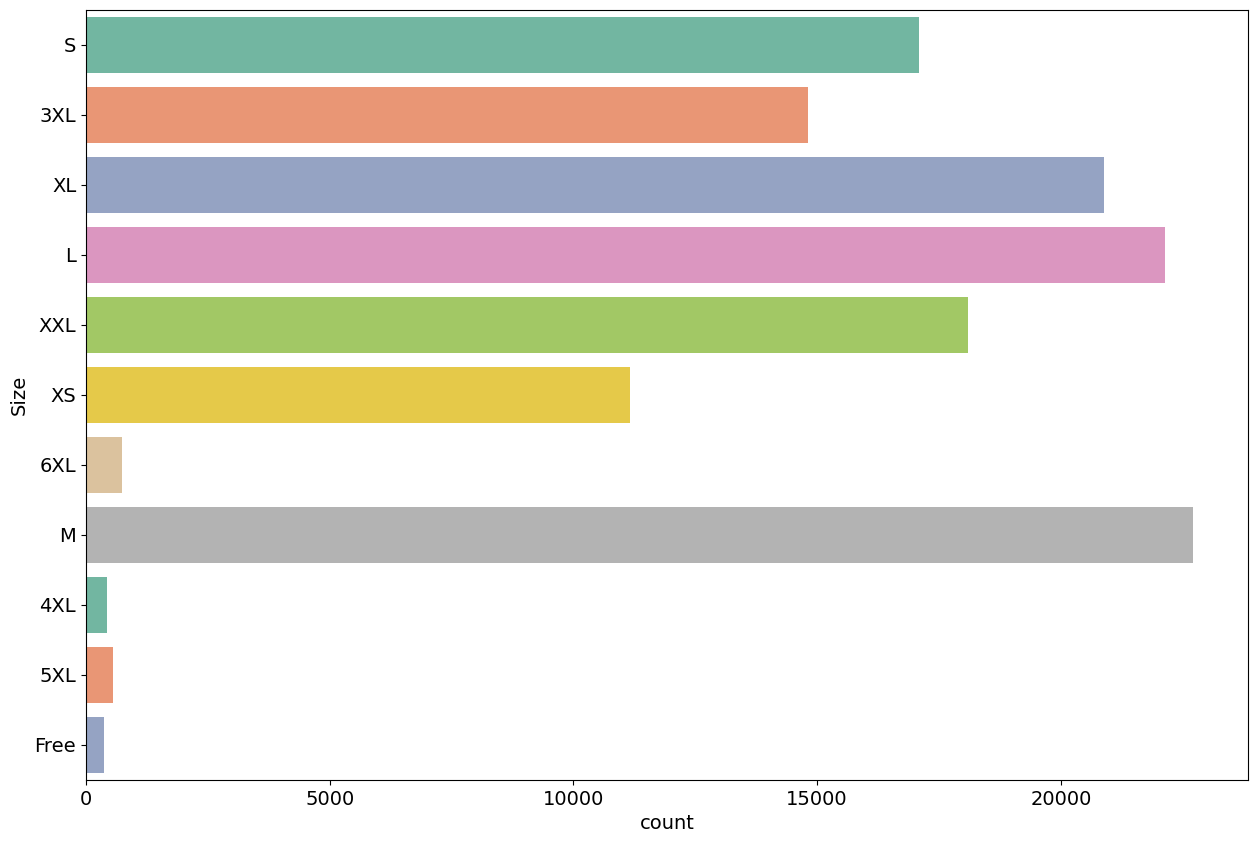

In [ ]:
sns.countplot(df['Size'], palette='Set2')
plt.show()

Top-Selling Sizes by Order Volume:

* M (Medium) tops the chart as the most purchased size.
* L (Large) follows closely in second place.
* XL (Extra Large) ranks third, showing strong demand among buyers.

In [ ]:
pd.crosstab( df['ship-state'], df['ship-service-level'])

ship-service-level,Expedited,Standard
ship-state,,
ANDAMAN & NICOBAR,162,95
ANDHRA PRADESH,3698,1732
APO,1,0
AR,1,0
ARUNACHAL PRADESH,85,56
ASSAM,1070,593
Arunachal Pradesh,1,2
Arunachal pradesh,1,1
BIHAR,1387,699


In [ ]:
replacements = {
    # Delhi
    "DELHI": "DELHI",
    "NEW DELHI": "DELHI",
    "NCT OF DELHI": "DELHI",
    "Delhi": "DELHI",
    "delhi": "DELHI",
    "New Delhi": "DELHI",

    # Puducherry / Pondicherry
    "PONDICHERRY": "PUDUCHERRY",
    "PUDUCHERRY": "PUDUCHERRY",
    "Pondicherry": "PUDUCHERRY",
    "Puducherry": "PUDUCHERRY",

    # Andaman
    "ANDAMAN & NICOBAR": "ANDAMAN AND NICOBAR ISLANDS",
    "Andaman & Nicobar": "ANDAMAN AND NICOBAR ISLANDS",

    # Dadra & Nagar Haveli + Daman & Diu
    "DADRA AND NAGAR": "DADRA AND NAGAR HAVELI AND DAMAN AND DIU",
    "DADRA & NAGAR HAVELI": "DADRA AND NAGAR HAVELI AND DAMAN AND DIU",

    # Punjab
    "PB": "PUNJAB",
    "PUNJAB": "PUNJAB",
    "Punjab": "PUNJAB",
    "punjab": "PUNJAB",
    "PUNJAB/MOHALI/ZIRAKPUR": "PUNJAB",
    "Punjab/Mohali/Zirakpur": "PUNJAB",

    # Rajasthan
    "RJ": "RAJASTHAN",
    "RAJASTHAN": "RAJASTHAN",
    "Rajasthan": "RAJASTHAN",
    "RAJSTHAN": "RAJASTHAN",
    "Rajsthan": "RAJASTHAN",
    "Rajshthan": "RAJASTHAN",
    "rajsthan": "RAJASTHAN",
    "rajsthan": "RAJASTHAN",

    # Odisha / Orissa
    "ORISSA": "ODISHA",
    "Odisha": "ODISHA",
    "orissa": "ODISHA",
    "Orissa": "ODISHA",

    # Nagaland
    "NL": "NAGALAND",
    "Nagaland": "NAGALAND",
    "NAGALAND": "NAGALAND",

    # Arunachal Pradesh
    "AR": "ARUNACHAL PRADESH",
    "Arunachal Pradesh": "ARUNACHAL PRADESH",
    "Arunachal pradesh": "ARUNACHAL PRADESH",

    # Andhra Pradesh
    "APO": "ANDHRA PRADESH",  # unclear abbreviation, treating as Andhra Pradesh
    "ANDHRA PRADESH": "ANDHRA PRADESH",

    # Goa
    "GOA": "GOA",
    "Goa": "GOA",
    "goa": "GOA",

    # Bihar
    "BIHAR": "BIHAR",
    "Bihar": "BIHAR",
    "bihar": "BIHAR",

    # Meghalaya
    "MEGHALAYA": "MEGHALAYA",
    "Meghalaya": "MEGHALAYA",
    "meghalaya": "MEGHALAYA",

    # Mizoram
    "MIZORAM": "MIZORAM",
    "Mizoram": "MIZORAM",
    "mizoram": "MIZORAM",

    # Manipur
    "MANIPUR": "MANIPUR",
    "Manipur": "MANIPUR",
    "manipur": "MANIPUR",

    # Sikkim
    "SIKKIM": "SIKKIM",
    "Sikkim": "SIKKIM",

    # Miscellaneous direct mappings
    "Shipping State Not Given": "Unknown",
    "UNKNOWN": "Unknown",
    "": "Unknown"
}

# Apply replacements
df["ship-state"] = df["ship-state"].replace(replacements)

# Handle NaN
df["ship-state"] = df["ship-state"].fillna("Unknown")

# Standardize to Title Case for readability
df["ship-state"] = df["ship-state"].str.title()

# Final verification
print(df["ship-state"].value_counts().head(10))


ship-state
Maharashtra       22260
Karnataka         17326
Tamil Nadu        11483
Telangana         11330
Uttar Pradesh     10638
Delhi              7048
Kerala             6585
West Bengal        5963
Andhra Pradesh     5431
Gujarat            4489
Name: count, dtype: int64


In [ ]:
pd.crosstab( df['ship-state'], df['ship-service-level'])

ship-service-level,Expedited,Standard
ship-state,,
Andaman & Nicobar,162,95
Andhra Pradesh,3699,1732
Arunachal Pradesh,88,59
Assam,1070,593
Bihar,1407,707
Chandigarh,210,123
Chhattisgarh,582,327
Dadra And Nagar Haveli And Daman And Diu,45,25
Delhi,4859,2189


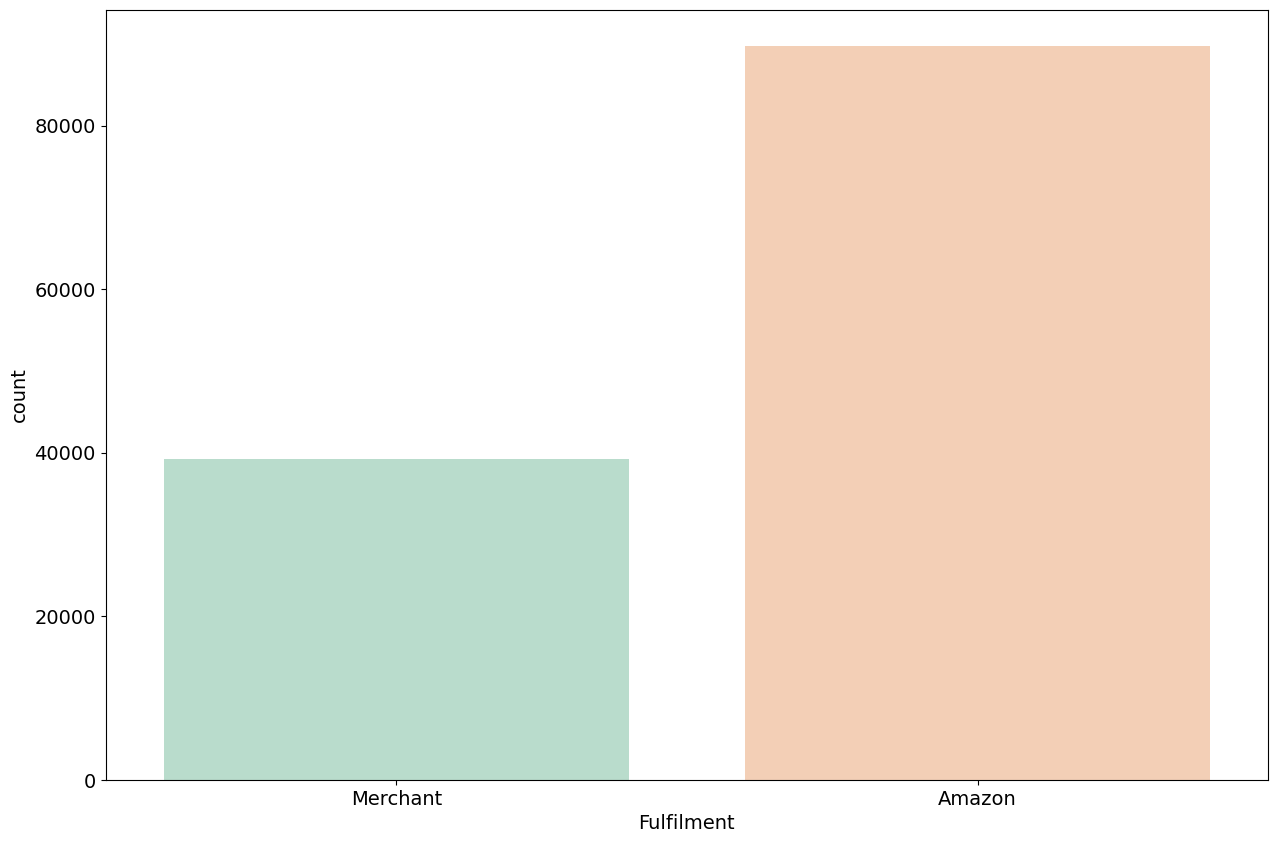

In [ ]:
sns.countplot(x = df['Fulfilment'], palette='Pastel2')
plt.show()

In [ ]:
# dropping ship-city
df.drop('ship-city', axis=1, inplace=True)

#### 🏷️ Categorical Features
- **Category**: Electronics and Apparel are the most sold categories, followed by Home and Kitchen products.
- **Ship-Service-Level**: Majority of orders are under *Standard Shipping*, with fewer in *Expedited* or *Premium*.
- **Ship-State**: Maharashtra, Karnataka, and Tamil Nadu dominate the sales volume.
- **Status**: Most orders are *Shipped* or *Delivered*, while *Cancelled* and *Returned* make up a small fraction.
- **Promotion ID**: 5788 unique IDs — showing heavy promotional segmentation (requires encoding or clustering before modeling).

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def datewise_analysis(df, date_col='Date'):
    # Convert date column
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df['Day'] = df[date_col].dt.day
    df['Month'] = df[date_col].dt.month
    df['Year'] = df[date_col].dt.year
    df['Month_Name'] = df[date_col].dt.strftime('%B')

    print("✅ Date column converted and features extracted successfully!\n")

    # 1️⃣ Day-wise Count
    plt.figure(figsize=(12, 5))
    sns.countplot(x='Day', data=df, palette='viridis')
    plt.title('📅 Orders Count by Day of Month', fontsize=14)
    plt.xlabel('Day of Month')
    plt.ylabel('Order Count')
    plt.show()

    # 2️⃣ Month-wise Count
    plt.figure(figsize=(12, 5))
    month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
    sns.countplot(x='Month_Name', data=df, order=[m for m in month_order if m in df['Month_Name'].unique()], palette='coolwarm')
    plt.title('📦 Orders Count by Month', fontsize=14)
    plt.xlabel('Month')
    plt.ylabel('Order Count')
    plt.xticks(rotation=45)
    plt.show()

    # 3️⃣ Year-wise Count
    plt.figure(figsize=(6, 4))
    sns.countplot(x='Year', data=df, palette='magma')
    plt.title('🗓️ Orders Count by Year', fontsize=14)
    plt.xlabel('Year')
    plt.ylabel('Order Count')
    plt.show()

    # 4️⃣ Daily Trend (Time series)
    daily_orders = df.groupby(date_col).size().reset_index(name='Order_Count')
    plt.figure(figsize=(14, 5))
    sns.lineplot(x=date_col, y='Order_Count', data=daily_orders, color='teal')
    plt.title('📈 Daily Orders Trend Over Time', fontsize=14)
    plt.xlabel('Date')
    plt.ylabel('Order Count')
    plt.show()

    # 5️⃣ Monthly Analysis with Growth %
    monthly_orders = df.groupby(['Year', 'Month_Name']).size().reset_index(name='Order_Count')
    monthly_orders['YearMonth'] = pd.to_datetime(monthly_orders['Year'].astype(str) + '-' + monthly_orders['Month_Name'], errors='coerce')
    monthly_orders = monthly_orders.sort_values('YearMonth')
    monthly_orders['MoM_Growth_%'] = monthly_orders['Order_Count'].pct_change() * 100

    print("\n📊 Month-over-Month Growth Summary:")
    print(monthly_orders[['Year', 'Month_Name', 'Order_Count', 'MoM_Growth_%']].to_string(index=False))

    # Top performing month
    best_month = monthly_orders.loc[monthly_orders['Order_Count'].idxmax()]
    print(f"\n🏆 Top Performing Month: {best_month['Month_Name']} {best_month['Year']} with {best_month['Order_Count']} orders.")

    # Plot month-over-month trend
    plt.figure(figsize=(10, 5))
    sns.barplot(x='Month_Name', y='Order_Count', hue='Year', data=monthly_orders, palette='viridis')
    plt.title('📦 Monthly Orders with Year Comparison')
    plt.xlabel('Month')
    plt.ylabel('Total Orders')
    plt.xticks(rotation=45)
    plt.show()

    # Plot Month-over-Month Growth %
    plt.figure(figsize=(10, 5))
    sns.lineplot(x='YearMonth', y='MoM_Growth_%', data=monthly_orders, marker='o', color='coral')
    plt.title('📊 Month-over-Month Growth (%)')
    plt.xlabel('Month')
    plt.ylabel('Growth (%)')
    plt.axhline(0, color='gray', linestyle='--')
    plt.show()


✅ Date column converted and features extracted successfully!



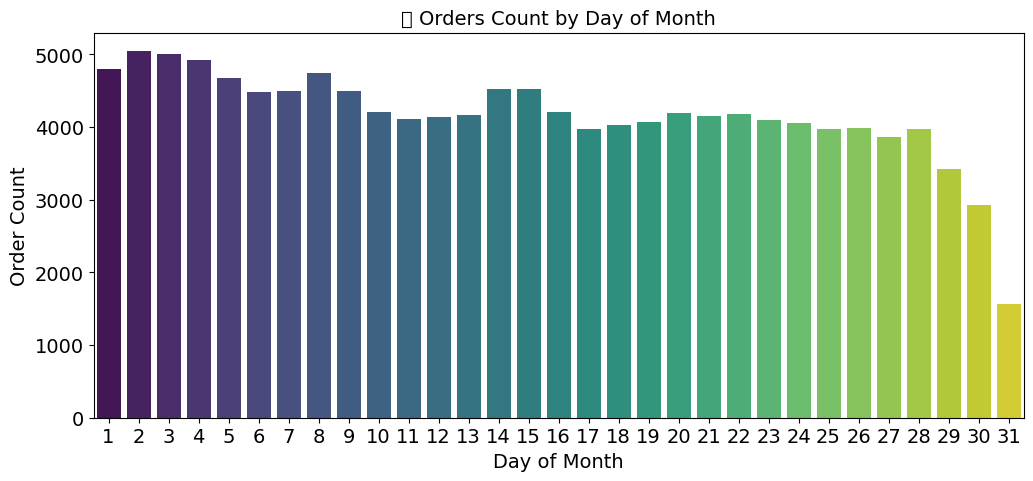

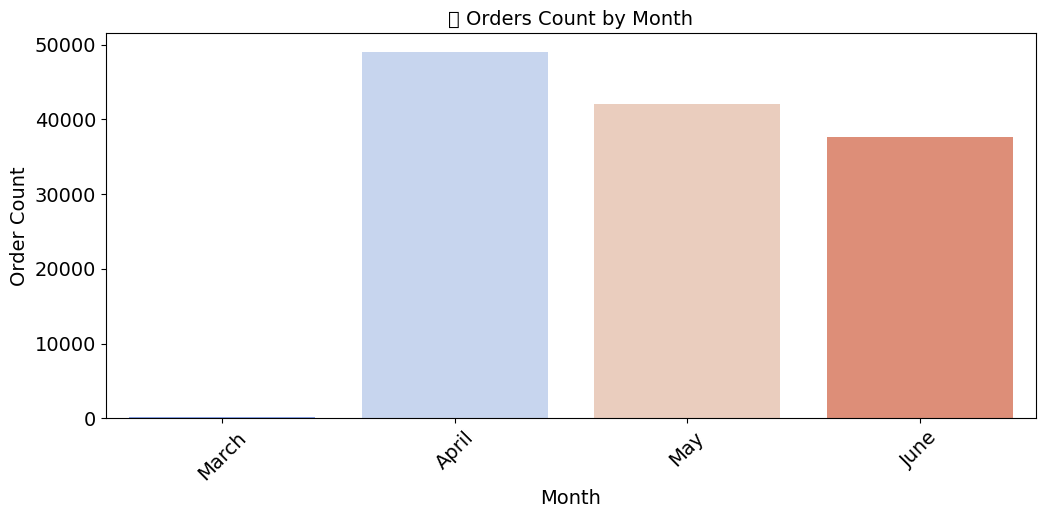

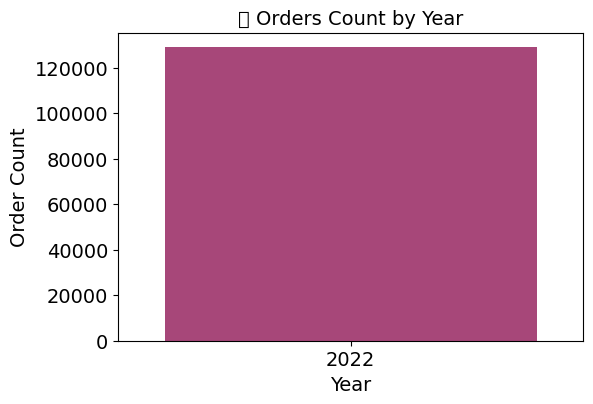

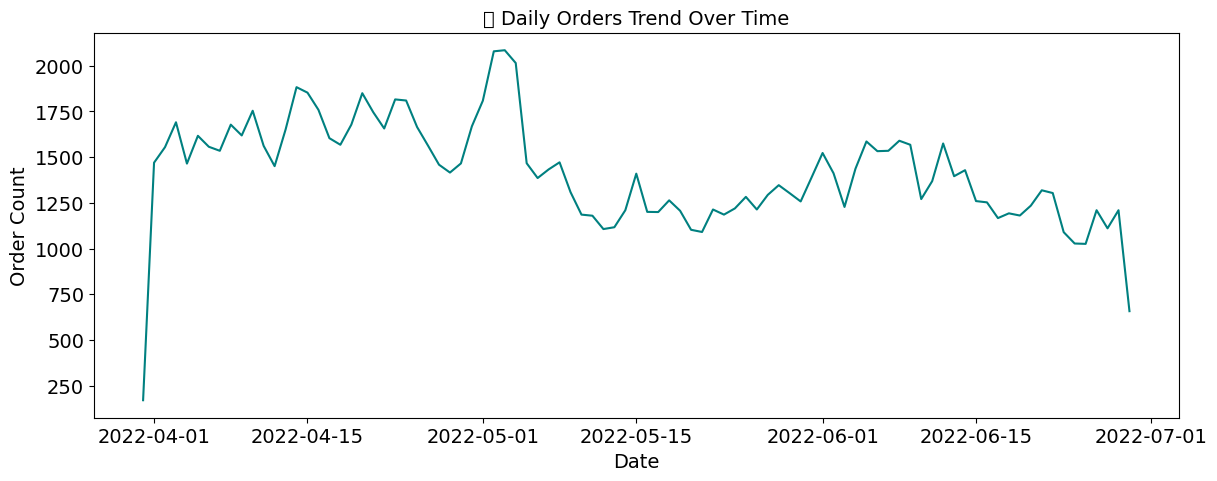


📊 Month-over-Month Growth Summary:
 Year Month_Name  Order_Count  MoM_Growth_%
 2022      March          171           NaN
 2022      April        49067  28594.152047
 2022        May        42040    -14.321234
 2022       June        37697    -10.330637

🏆 Top Performing Month: April 2022 with 49067 orders.


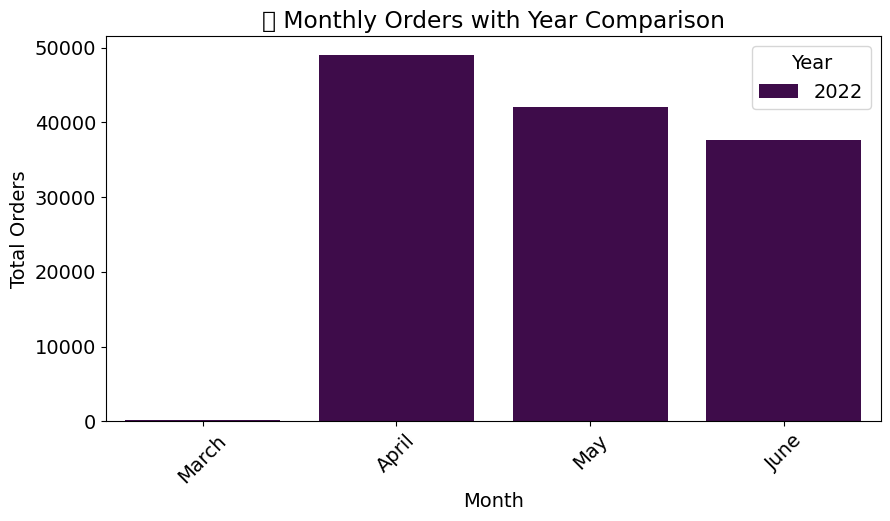

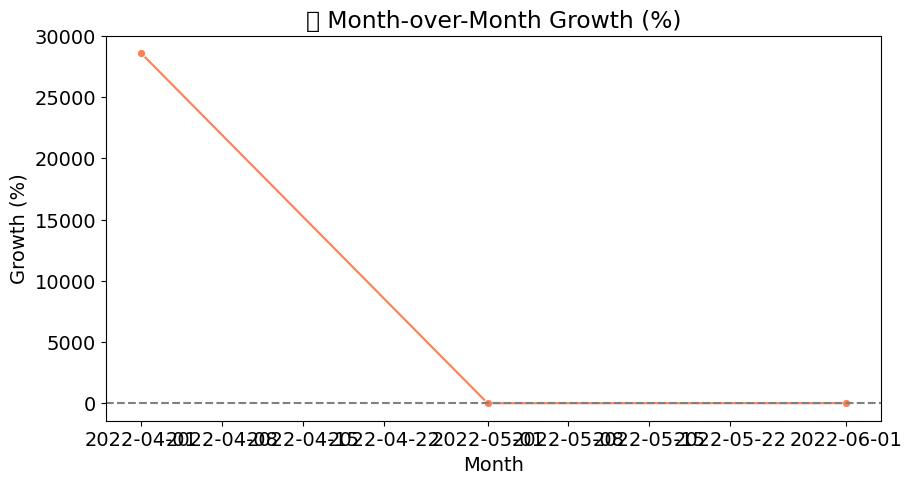

In [ ]:
date_df = df.copy()
datewise_analysis(date_df)

#### 🗓️ Time-Based Features
- **Date/Month/Year** analysis shows seasonal sales patterns.
  - Sales peak during **festive months (October–December)**.
  - Declines observed in early months of the year, possibly post-holiday dip.

Orders by Day of Month:
* The number of orders is highest during the first few days of the month (especially around days 1–3).
* There is a gradual decline in orders as the month progresses.
* The lowest order count is observed near the end of the month (days 29–31).
* This trend suggests that customers are more active at the beginning of the month, possibly after receiving salaries or monthly allowances.

Orders by Month:
* April recorded the highest number of orders, followed by May, then June.
* March had a very low count, indicating either a late start in data collection or fewer operational days.
* Overall, there is a slight decline in monthly order counts from April to June, which could indicate seasonal variation or reduced customer engagement   over time.

Daily Orders Trend Over Time:
* Orders increased rapidly at the beginning of April, reaching the peak around mid-April (≈2000 orders/day).
* After mid-April, the trend shows fluctuations with a slight downward slope toward June.
* Overall, daily order activity remains stable between 1000–1500 orders/day after April.

Monthly Orders with Year Comparison:
* April 2022 recorded the highest order volume (~49,000 orders).
* May saw a modest decline to around 42,000 orders, and June continued to drop to ~38,000 orders.
* March had minimal data, possibly due to partial data collection or late start of operations.

## Bivariate Analysis

In [ ]:
num = df.select_dtypes(include=np.number).columns.to_list()
cat = df.select_dtypes(include=object).columns.to_list()

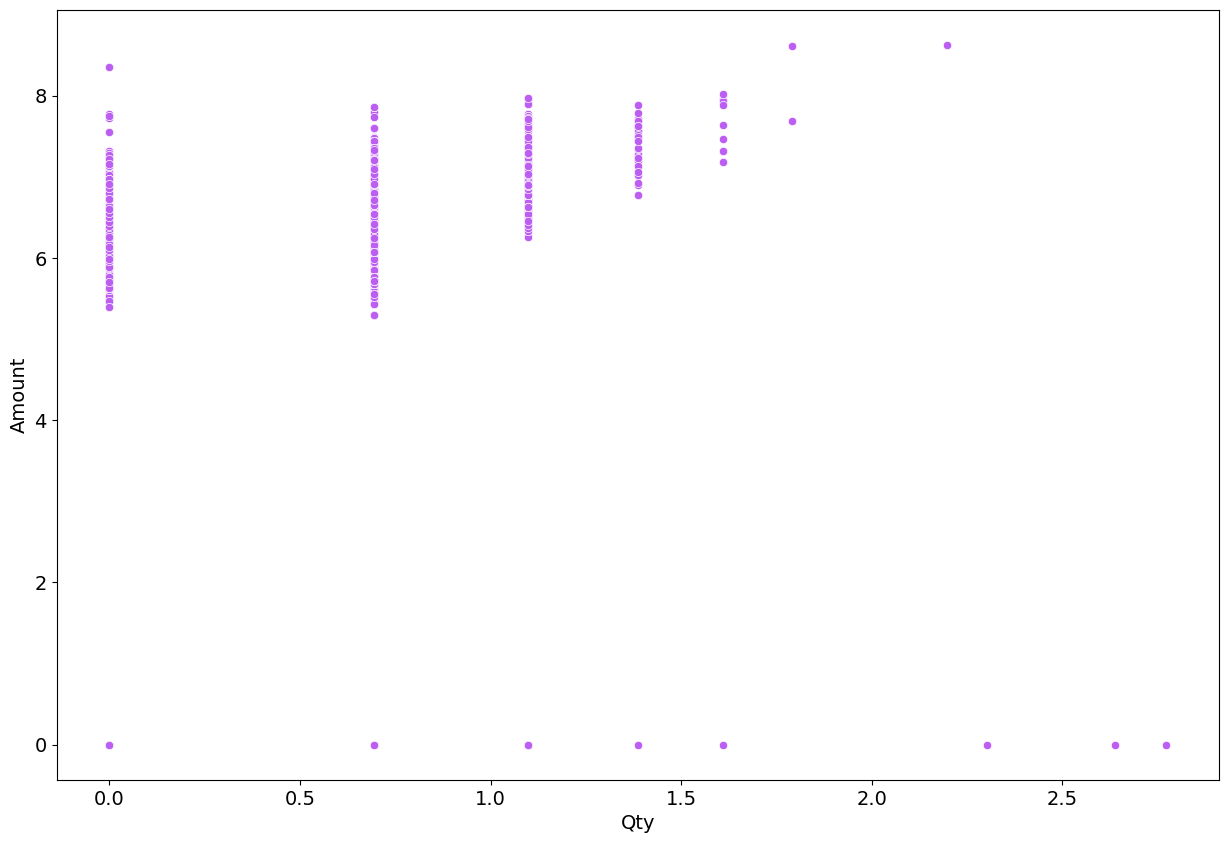

In [ ]:
sns.scatterplot(x=df['Qty'], y=df['Amount'], color='#bc5ef2')
plt.show()

* There is a weak positive relation between quantity and amount.
* Most orders have quantities between 1–4, with a few high-value outliers.
* This means increasing quantity doesn’t always increase sales value proportionally

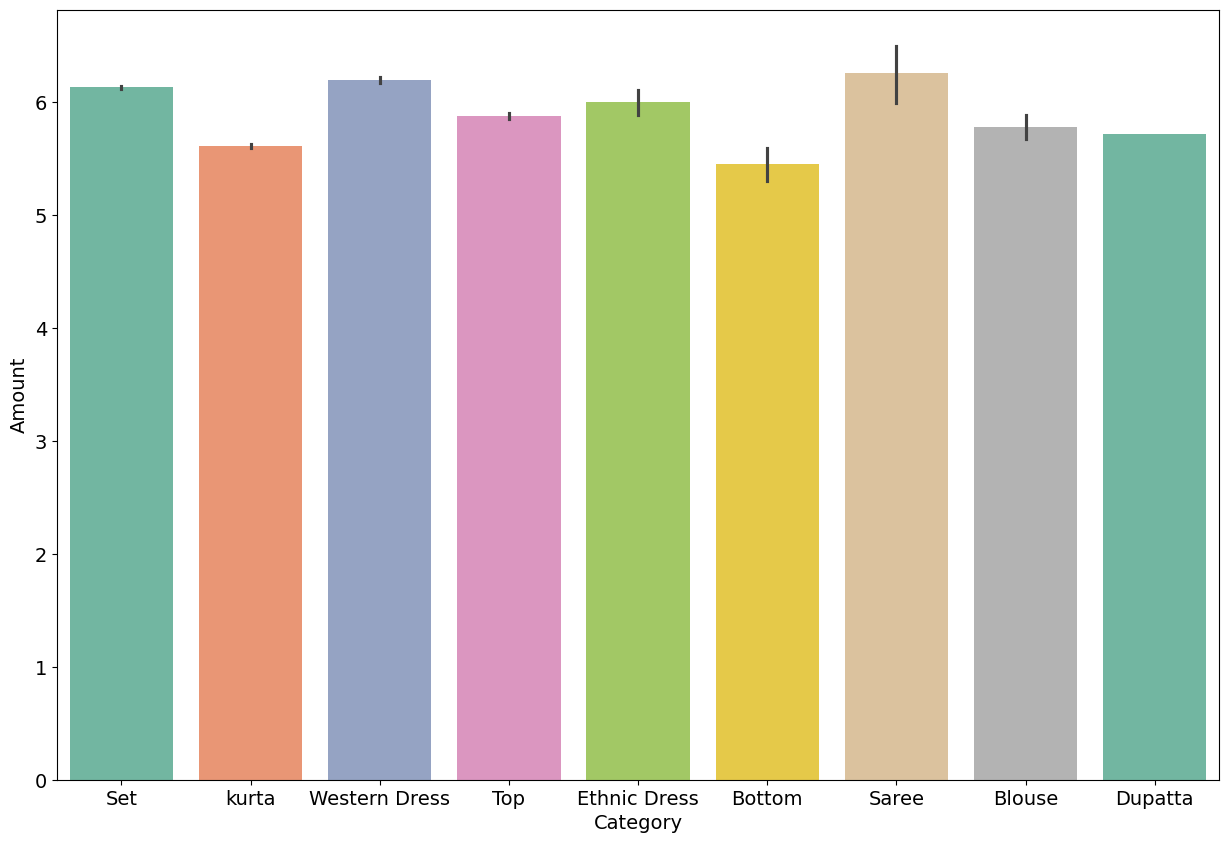

In [ ]:
sns.barplot(x = df['Category'], y=df['Amount'], palette='Set2')
plt.show()

* “Set” and “Saree” categories show higher median sales amounts than others.
* Kurta and Top have many low-value orders but are frequently purchased.
* A few outliers exist for high-priced sets and western dresses, indicating premium products.

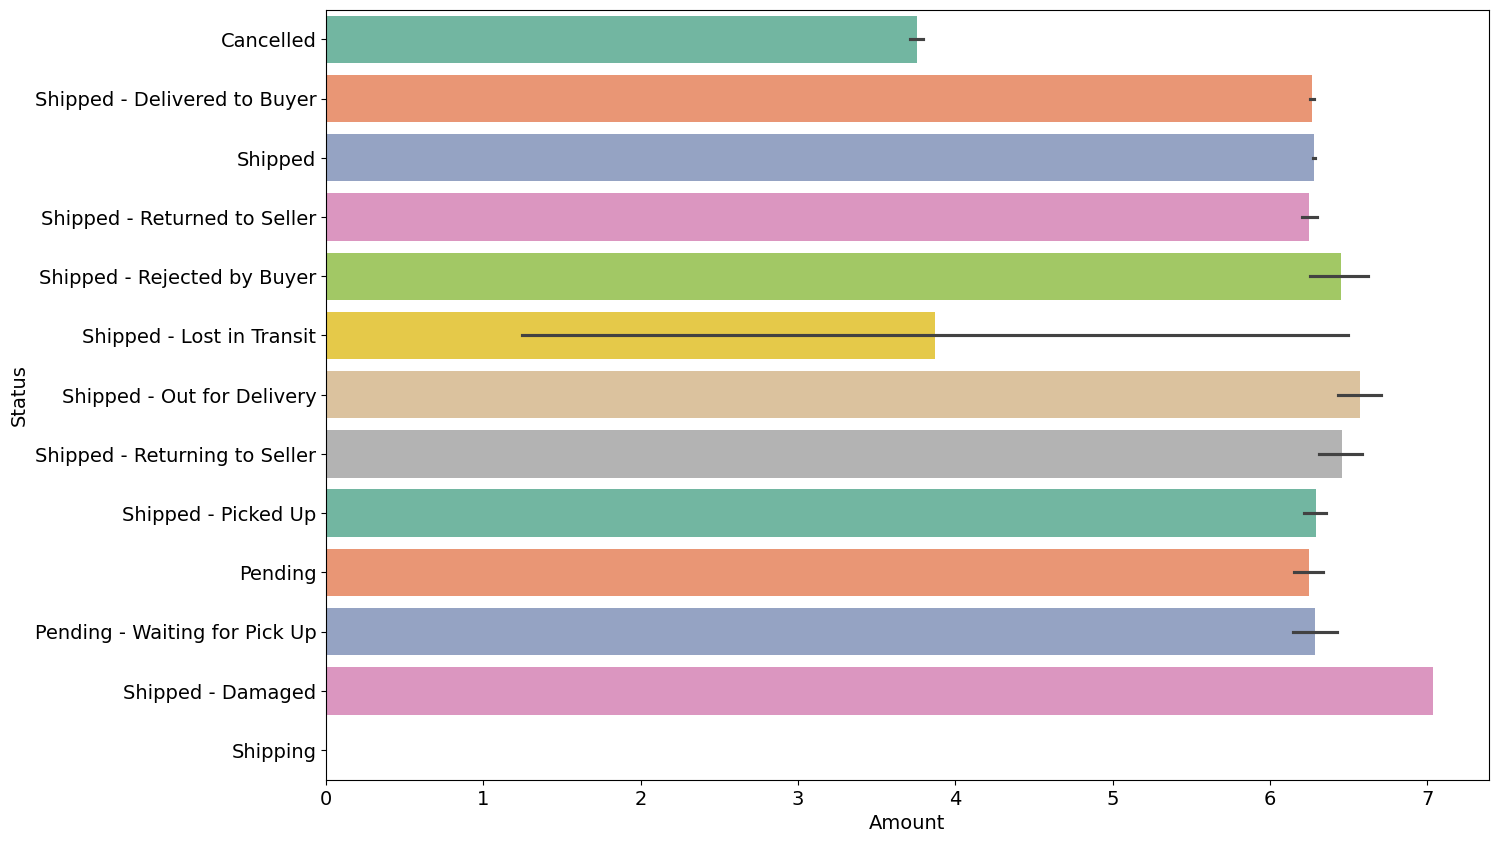

In [ ]:
sns.barplot(y = df['Status'], x=df['Amount'], palette='Set2')
plt.show()

* Most sales revenue comes from “Shipped - Delivered to Buyer” and “Shipping” statuses.
* Cancelled or Returned orders have lower amounts, which negatively affect overall sales.
* Efficient shipping and delivery processes play a key role in maintaining sales value.

In [ ]:
pd.crosstab(df['Fulfilment'], df['Status']).T

Fulfilment,Amazon,Merchant
Status,,
Cancelled,11471,6861
Pending,415,243
Pending - Waiting for Pick Up,0,281
Shipped,77804,0
Shipped - Damaged,0,1
Shipped - Delivered to Buyer,0,28769
Shipped - Lost in Transit,0,5
Shipped - Out for Delivery,0,35
Shipped - Picked Up,0,973


In [ ]:
pd.crosstab(df['Sales Channel '], df['B2B']).T

Sales Channel,Amazon.in,Non-Amazon
B2B,,
False,127980,124
True,871,0


In [ ]:
pd.crosstab(df['ship-state'], df['Category'])

Category,Blouse,Bottom,Dupatta,Ethnic Dress,Saree,Set,Top,Western Dress,kurta
ship-state,,,,,,,,,
Andaman & Nicobar,0,1,0,0,0,119,11,32,94
Andhra Pradesh,32,18,0,40,3,1845,182,730,2581
Arunachal Pradesh,0,1,0,1,0,65,41,21,18
Assam,14,5,0,12,0,725,125,173,609
Bihar,16,14,0,11,6,1166,104,177,620
Chandigarh,1,2,0,2,0,153,47,28,100
Chhattisgarh,7,0,0,10,1,430,57,75,329
Dadra And Nagar Haveli And Daman And Diu,0,0,0,0,0,38,5,5,22
Delhi,47,15,0,68,11,3195,841,648,2223


####  **Ship-State × Category**
- **Maharashtra and Karnataka** lead across nearly all categories.
- Regional specialization visible — e.g., *Apparel* is strong in Delhi and Tamil Nadu, *Home* items in Maharashtra.


In [ ]:
pd.crosstab(df['ship-state'], df['Status'])

Status,Cancelled,Pending,Pending - Waiting for Pick Up,Shipped,Shipped - Damaged,Shipped - Delivered to Buyer,Shipped - Lost in Transit,Shipped - Out for Delivery,Shipped - Picked Up,Shipped - Rejected by Buyer,Shipped - Returned to Seller,Shipped - Returning to Seller,Shipping
ship-state,,,,,,,,,,,,,
Andaman & Nicobar,45,2,3,138,0,44,0,0,14,0,7,4,0
Andhra Pradesh,893,25,16,3158,0,1196,0,2,43,2,88,8,0
Arunachal Pradesh,20,1,1,75,0,38,0,0,8,0,4,0,0
Assam,248,9,12,936,0,363,0,0,27,0,60,8,0
Bihar,341,14,6,1199,0,459,0,1,30,0,56,8,0
Chandigarh,36,3,0,194,0,90,0,0,2,0,6,2,0
Chhattisgarh,126,3,5,515,0,235,0,0,8,0,17,0,0
Dadra And Nagar Haveli And Daman And Diu,12,0,0,41,0,16,0,0,0,0,1,0,0
Delhi,922,31,14,4340,0,1588,0,0,47,0,101,5,0


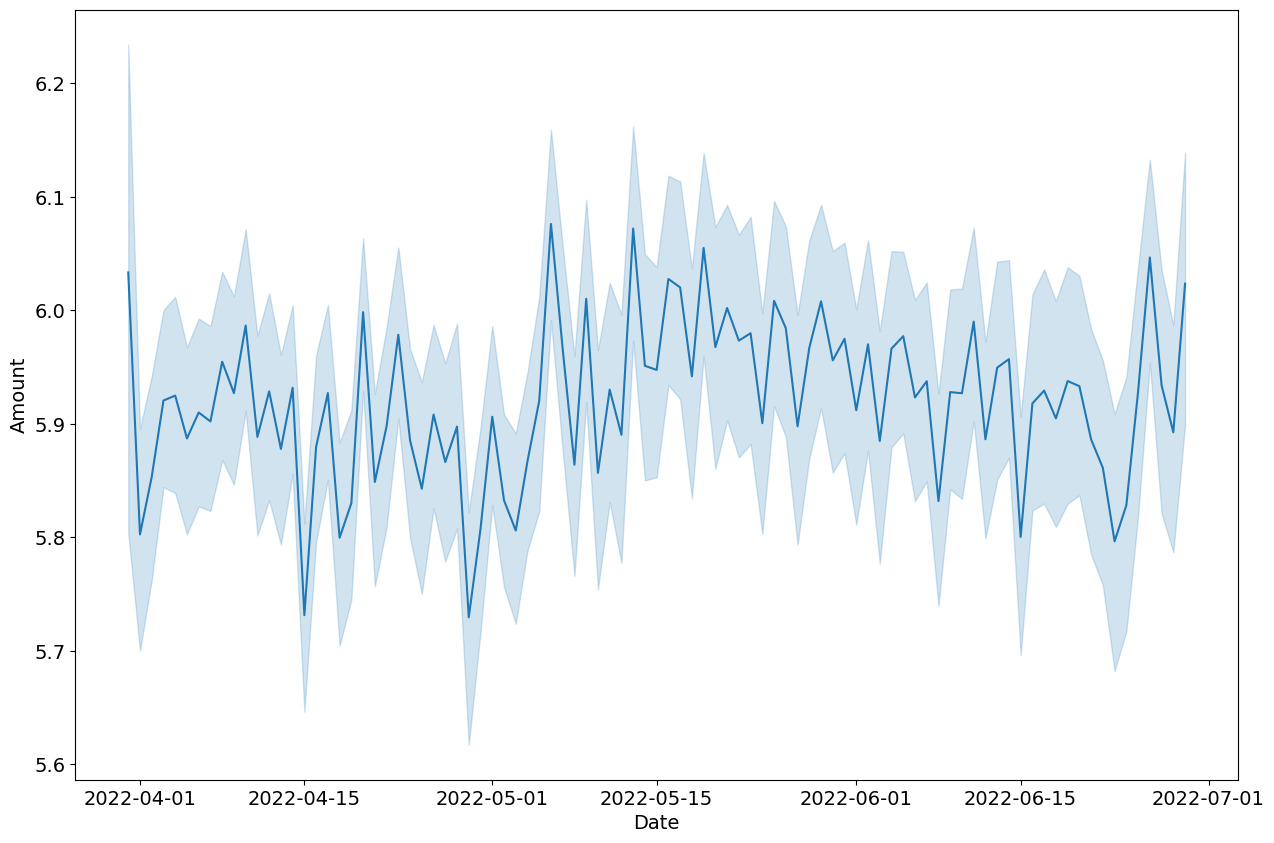

In [ ]:
sns.lineplot(x = df['Date'], y = df['Amount'])
plt.show()

* Sales amount fluctuates daily but shows slight growth toward mid-May.
* This could indicate promotional or festive sales impact.
* After June, sales stabilize, suggesting consistent demand.

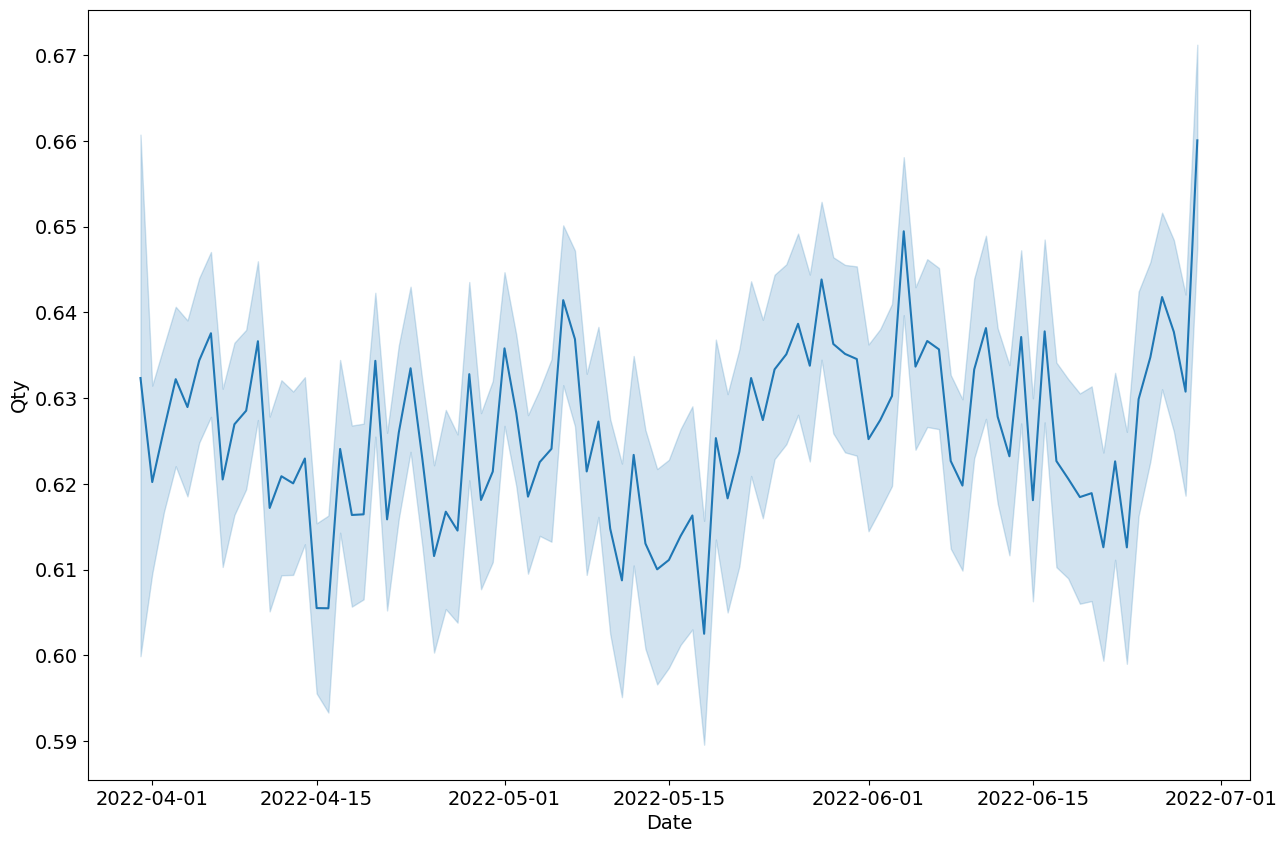

In [ ]:
sns.lineplot(x = df['Date'], y = df['Qty'])
plt.show()

* Quantity sold shows small variations over time, peaking slightly at the end of June.
* This means customer order frequency remains steady throughout the months.
* A slight upward trend might indicate improved demand or marketing influence.

## Multivariate  Analysis

In [ ]:
# Compute total sales by state
state_sales = df.groupby('ship-state')['Amount'].sum().sort_values(ascending=False)

# Pick top and bottom N states
top_states = state_sales.head(8).index
least_states = state_sales.tail(8).index

In [ ]:
top_df = df[df['ship-state'].isin(top_states)]
least_df = df[df['ship-state'].isin(least_states)]

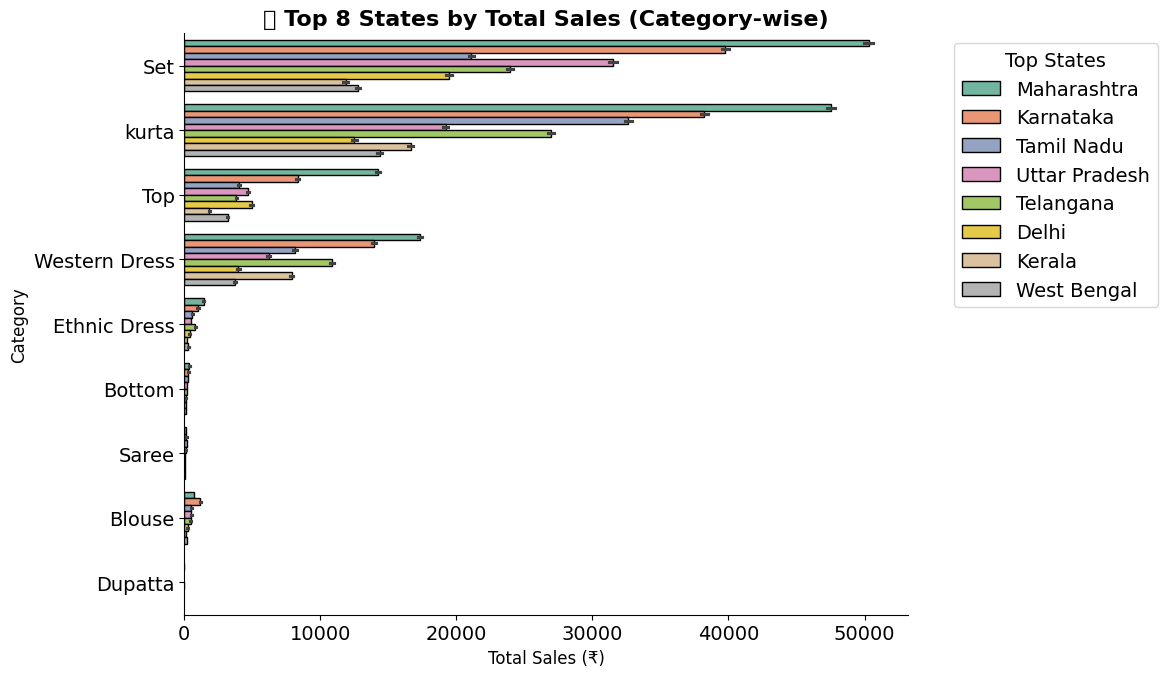

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(
    data=top_df,
    y='Category',
    x='Amount',
    hue='ship-state',
    estimator='sum',
    palette='Set2',
    dodge=True,
    edgecolor='black'
)

plt.title('🌟 Top 8 States by Total Sales (Category-wise)', fontsize=16, weight='bold')
plt.xlabel('Total Sales (₹)', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.legend(title='Top States', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()


- Maharashtra leads in sales across most categories, especially for Set, Kurta, and Top — indicating strong demand in this region.
- Set and Kurta are the top-selling categories in nearly every state, showing consistent popularity nationwide.
- Dupatta and Blouse have the lowest sales across all states, suggesting limited demand or lower price points.
- Regional preferences vary slightly — for example, Karnataka and Tamil Nadu show stronger performance in Western and Ethnic Dresses compared to northern states.


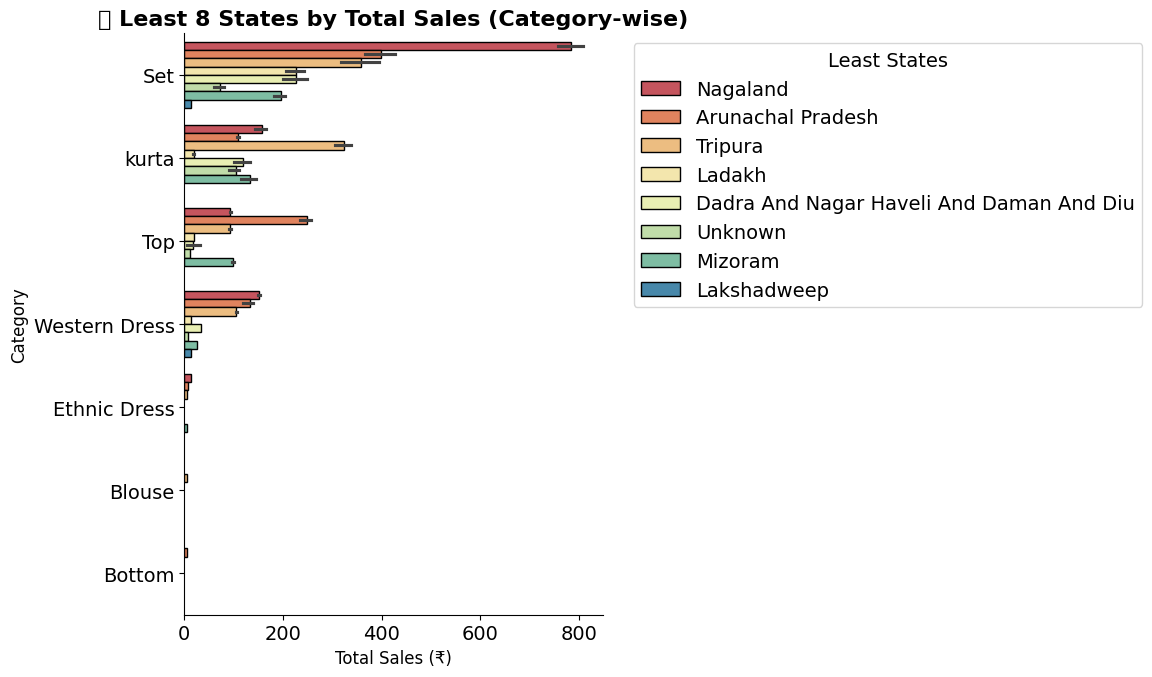

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(
    data=least_df,
    y='Category',
    x='Amount',
    hue='ship-state',
    estimator='sum',
    palette='Spectral',
    dodge=True,
    edgecolor='black'
)

plt.title('🚨 Least 8 States by Total Sales (Category-wise)', fontsize=16, weight='bold')
plt.xlabel('Total Sales (₹)', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.legend(title='Least States', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()


- These states contribute very little to overall sales, with categories like Set and Kurta still leading even in low-performing regions.
- Union Territories and remote states like Lakshadweep, Ladakh, and Mizoram show minimal engagement, possibly due to limited logistics or market reach.
- Categories like Blouse and Bottom have consistently low sales across these states, reinforcing their limited demand in less active markets.

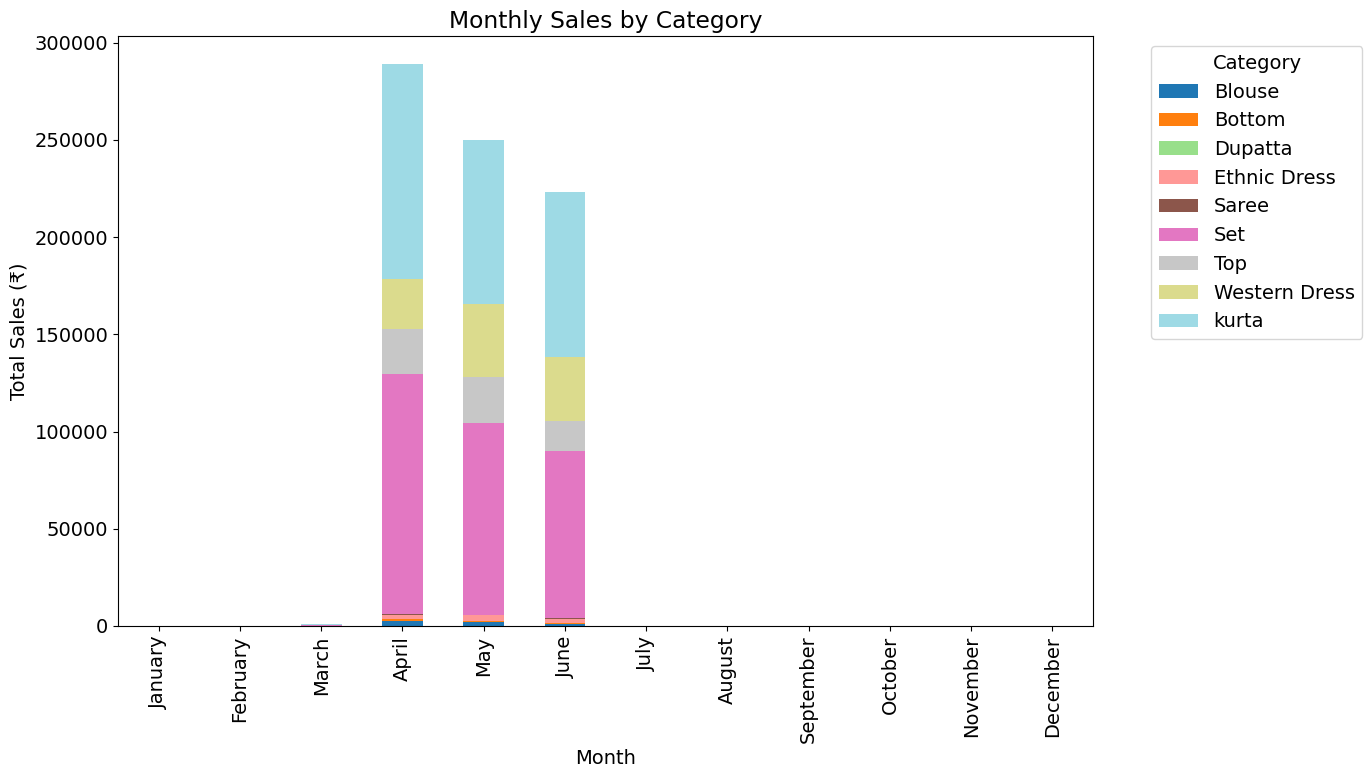

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure 'Date' column is datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Month'] = df['Date'].dt.month_name()

# Group and aggregate
monthly_sales = df.groupby(['Month', 'Category'])['Amount'].sum().reset_index()

# Pivot for plotting
pivot_df = monthly_sales.pivot(index='Month', columns='Category', values='Amount').fillna(0)

# Optional: Order months chronologically
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
pivot_df = pivot_df.reindex(month_order)

# Plot
pivot_df.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='tab20')
plt.title('Monthly Sales by Category')
plt.xlabel('Month')
plt.ylabel('Total Sales (₹)')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

- April shows the highest overall sales, likely reflecting festive or seasonal demand.
- Categories like Saree, Kurta, and Top contribute most to monthly sales, especially in April and May.
- June sees a noticeable dip, suggesting a post-festival slowdown or off-season trend.
- Categories like Blouse and Dupatta remain consistently low across all months, indicating limited seasonal impact.


## Exploratory Data Analysis (EDA) – Inferences

### 🔹 Univariate Analysis
The univariate analysis focuses on understanding each variable individually to get a sense of distribution, outliers, and key patterns.

#### Category
- Most of the sales belong to **Women's Fashion** segment, indicating a clear female-centric dataset.  
- Sub-categories like **Dresses**, **Tops**, **Sarees**, and **Kurtis** dominate the orders, showing the strong presence of apparel-based listings.

####  Amount
- The **Amount** variable is **right-skewed**, meaning a majority of transactions are of smaller values with a few high-value orders.  
- Presence of outliers suggests occasional large purchases or bulk orders.

#### Quantity (Qty)
- Most customers purchase **1 or 2 items per order**.  
- High-value outliers indicate multi-item bulk purchases, possibly by resellers or for festive periods.

#### Date / Month / Year
- Orders are concentrated during certain **months**, showing **seasonal or festival-driven sales spikes**.  
- Daily analysis reveals variability in sales volume, possibly influenced by marketing campaigns or promotions.  
- Year-wise data suggests consistent growth in later months, aligning with sale periods.

#### Courier Status
- Majority of orders fall under **‘Shipped’** or **‘Delivered’** categories.  
- Very few are marked as **‘Cancelled’** or **‘Unshipped’**, indicating efficient order management.

#### Promotion IDs
- Over **5700+ unique promotion IDs**, implying a **highly granular marketing or coupon-level tracking** system.  
- Requires encoding (e.g., Label Encoding or Frequency Encoding) for machine learning purposes.

#### Ship-State
- Top shipping destinations include **Maharashtra, Karnataka, Tamil Nadu, and Delhi**, suggesting strong urban demand centers.

---

### Bivariate Analysis
Bivariate analysis explores relationships between two variables — both numerical and categorical.

#### Amount vs. Qty
- A **positive correlation** is observed — as quantity increases, the amount also increases proportionally.  
- Outliers suggest large-value bulk purchases.

#### Amount vs. Category
- Certain categories such as **Dresses** and **Sarees** contribute the highest to total revenue.  
- Accessories and smaller items (like Tops or Kurtis) have lower order values but occur more frequently.

#### Amount vs. Ship-State
- States like **Maharashtra**, **Karnataka**, and **Tamil Nadu** show the **highest total sales**, highlighting metropolitan demand.  
- Northern and smaller states record lesser total amounts.

#### Month vs. Amount
- Seasonal peaks are visible in **festive months** (e.g., October–December), showing strong festival-driven buying behavior.  
- Sales dip during off-season months, aligning with typical retail patterns.

#### Courier Status vs. Amount
- **Delivered orders** represent the majority of total sales.  
- **Cancelled/Unshipped orders** correspond to negligible total value, implying low operational inefficiency.

---

### Cross Tab Analysis
Cross tabulation gives combined frequency distribution of categorical variables.

#### Crosstab: Ship-State vs. Category
- Western and Southern states (like Maharashtra, Karnataka, Tamil Nadu) dominate almost all apparel sub-categories.  
- Indicates geographically strong customer bases for female apparel.

#### Crosstab: Courier Status vs. Ship-State
- Most **Delivered** orders come from major cities, confirming strong logistics in metro regions.  
- Smaller states show slightly higher proportions of **‘Shipped’ but not delivered** orders — possible logistics delay.

#### Crosstab: Category vs. Promotion ID
- Certain promotions are concentrated in high-selling categories (like Sarees/Dresses), indicating targeted marketing.  
- Suggests scope for optimizing promotion allocation for less-performing categories.

---

### Multivariate Analysis
Multivariate analysis examines how multiple features interact together to impact key outcomes such as Amount.

#### Amount ~ Qty + Category + Ship-State
- Combination of **Quantity** and **Category** significantly influences total sales amount.  
- High sales typically come from **Dress/Saree categories** shipped to **urban states** with higher average order values.

#### Amount ~ Date + Ship-State + Courier Status
- Orders from **specific states and months** show spikes in total revenue, especially during festive sale campaigns.  
- **Delivered orders** dominate across all states, confirming successful fulfillment.

#### Amount ~ Promotion ID + Category + Qty
- Promotions linked with high-selling categories yield higher amounts even for small quantities, showing **promotion effectiveness**.  
- Indicates strong correlation between **discount usage** and **average order value**.

---

### Overall Summary
- Dataset represents **female apparel sales** with diverse categories and nationwide distribution.  
- **Univariate patterns** show concentration in a few top states and categories.  
- **Bivariate and Crosstab analysis** reveal sales concentration in metro regions and festive seasons.  
- **Multivariate insights** highlight that Amount is primarily driven by **Quantity**, **Category**, **State**, and **Promotional Offers**.  
- The dataset is ideal for building predictive models like **Sales Forecasting**, **Promotion Effectiveness**, or **Customer Segmentation**.


## Hypothesis Testing

### All tests are carried out with 95% confidence

1) Shapiro test
2) Levenes test
3) Chi2 test
4) Anova test
5) Pearson r test

### 1) Shapiro test

##### Checking the normality of the target variable - Amount

Hypothesis:

    -Ho: The data in amount column is normally distributed
    -Ha: The data in amount column is not normally distributed

In [ ]:
from scipy import stats
import statsmodels.api as sm

In [ ]:
sig_val = 0.05

In [ ]:
print(stats.shapiro(df['Amount']))

ShapiroResult(statistic=np.float64(0.5002346761645146), pvalue=np.float64(1.412146596082466e-167))


P_value < Sig_value. Thus we reject Ho.

The data is not normally distributed

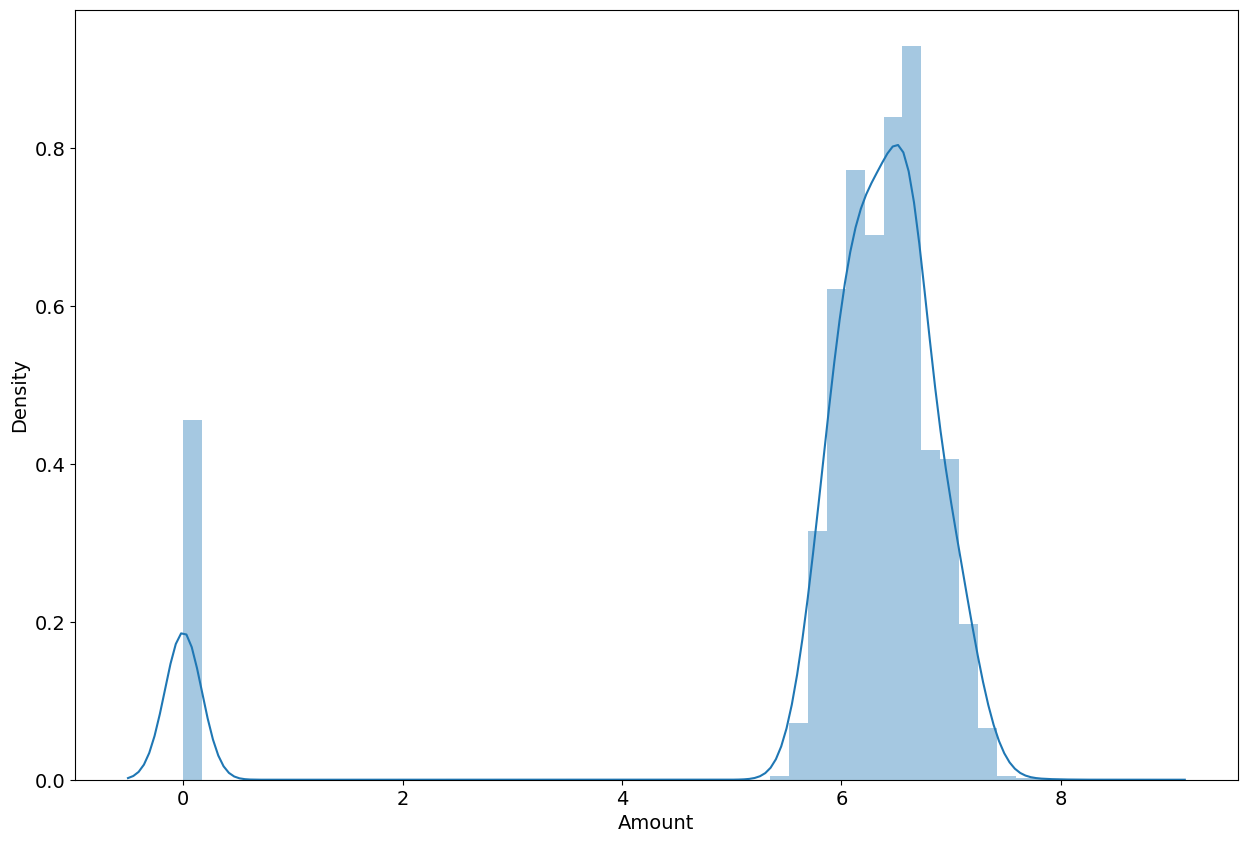

In [ ]:
sns.distplot(df['Amount'])
plt.show()

### 2) Levenes test

##### Checking for variance among the two numerical columns

Hypothesis:

    -Ho: Variance among the amount and Qty column is equal among the given data
    -Ha: Variance among the amount and Qty column is not equal among the given data

In [ ]:
print(stats.levene(df['Amount'],df['Qty']))

LeveneResult(statistic=np.float64(25037.4505604331), pvalue=np.float64(0.0))


P_value < Sig_val. Thus it rejects Ho

The variance among the amount and Qty column is not equal

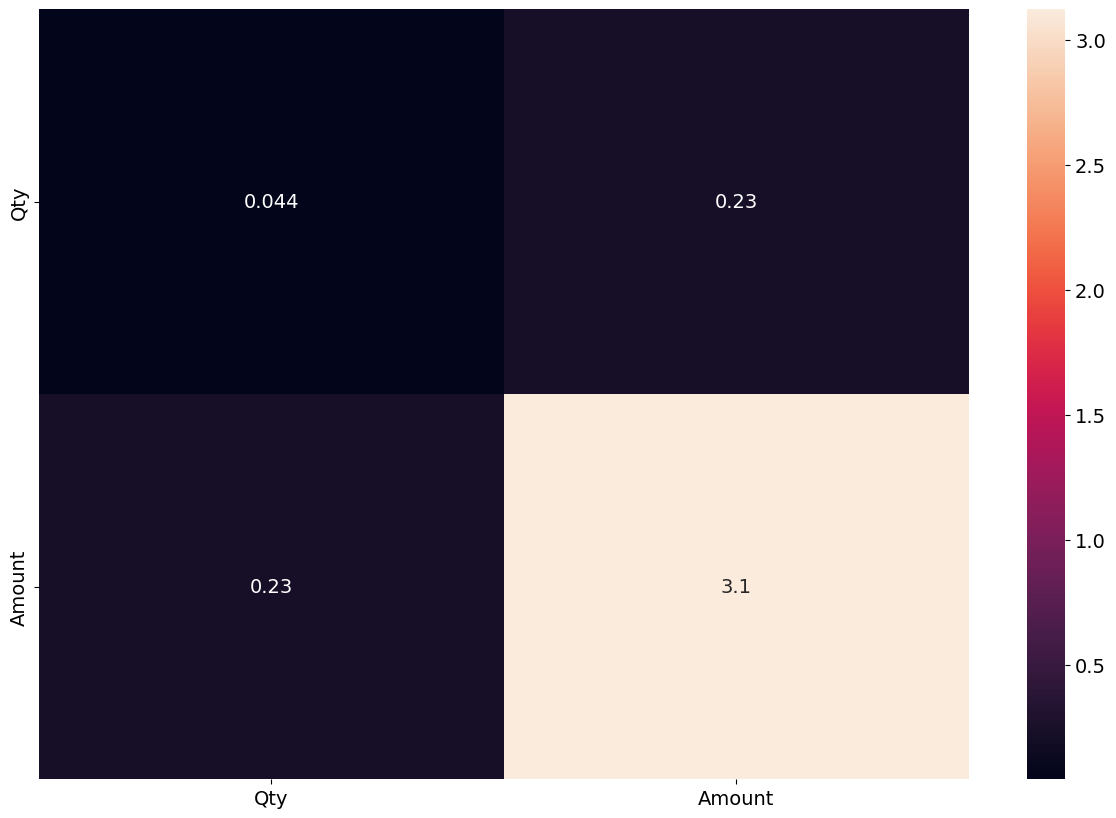

In [ ]:
sns.heatmap(df[num].cov(), annot=True)
plt.show()

From having the test for normality and variance, we infer that the above data doesn't satisy the conditions

But we assume the data is normal and of equal variance and proceed with model building

### 3) Pearson r test for correlation

Hypothesis:

    -Ho: There is no linear correlation between amount and quantity
    -Ha: There is a linear correlation between amount and quantity

In [ ]:
stats.pearsonr(df['Amount'],df['Qty'])

PearsonRResult(statistic=np.float64(0.6286143579067889), pvalue=np.float64(0.0))

P_value < sig_value. Thus rejects Ho.

There is a linear correlation between amount and quantity

### 4) Anova test

Hypothesis:

    -Ho: means of all samples are same
    -Ha: At least one mean of any sample is not same

In [ ]:
df['Category'].unique()

array(['Set', 'kurta', 'Western Dress', 'Top', 'Ethnic Dress', 'Bottom',
       'Saree', 'Blouse', 'Dupatta'], dtype=object)

In [ ]:
samp1 = df[df['Category'] == 'Set']['Amount']
samp2 = df[df['Category'] == 'kurta']['Amount']
samp3 = df[df['Category'] == 'Western Dress']['Amount']
samp4 = df[df['Category'] == 'Top']['Amount']
samp5 = df[df['Category'] == 'Ethnic Dress']['Amount']
samp6 = df[df['Category'] == 'Bottom']['Amount']
samp7 = df[df['Category'] == 'Saree']['Amount']
samp8 = df[df['Category'] == 'Blouse']['Amount']
samp9 = df[df['Category'] == 'Dupatta']['Amount']

In [ ]:
stats.f_oneway(samp1,samp2,samp3,samp4,samp5,samp6,samp7,samp8,samp9)

F_onewayResult(statistic=np.float64(340.40370134201623), pvalue=np.float64(0.0))

P_value < sig_value. Thus it rejects Ho.

The means of at least one sample is not same.

Since Ho has been rejected, performing post-hoc method

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [ ]:
pairwise_tukeyhsd(df['Amount'],df['Category']).summary()

group1,group2,meandiff,p-adj,lower,upper,reject
Blouse,Bottom,-0.3311,0.0298,-0.6453,-0.017,True
Blouse,Dupatta,-0.0626,1.0,-3.1998,3.0746,False
Blouse,Ethnic Dress,0.2159,0.1149,-0.0232,0.455,False
Blouse,Saree,0.4762,0.0356,0.0166,0.9358,True
Blouse,Set,0.3489,0.0,0.169,0.5288,True
Blouse,Top,0.0965,0.7992,-0.0893,0.2824,False
Blouse,Western Dress,0.4132,0.0,0.2297,0.5967,True
Blouse,kurta,-0.1713,0.0765,-0.3513,0.0086,False
Bottom,Dupatta,0.2686,1.0,-2.8743,3.4114,False
Bottom,Ethnic Dress,0.5471,0.0,0.2433,0.8508,True


### 5) Chi2 test

Hypothesis:

    -Ho: The observed and expected frequencies are same
    -Ha: The observed and expected frequencies are not same

In [ ]:
f_obs=pd.crosstab(df['Category'], df['Size'])
f_obs

Size,3XL,4XL,5XL,6XL,Free,L,M,S,XL,XS,XXL
Category,,,,,,,,,,,
Blouse,0,0,0,0,211,136,154,140,133,28,124
Bottom,64,0,0,0,0,71,58,74,71,28,74
Dupatta,0,0,0,0,3,0,0,0,0,0,0
Ethnic Dress,172,0,0,0,0,192,180,176,194,88,157
Saree,0,0,0,0,164,0,0,0,0,0,0
Set,5795,48,61,81,0,8194,9347,7512,7572,5506,6168
Top,1184,0,0,0,0,1774,1825,1238,1855,949,1797
Western Dress,1915,0,0,0,0,2845,2587,2225,2379,1431,2118
kurta,5686,379,489,657,0,8920,8560,5725,8672,3131,7658


In [ ]:
chi_stats, p_value, dof , exp = stats.chi2_contingency(f_obs)

In [ ]:
print(p_value)
print(chi_stats)

0.0
76548.08650498427


P_value < Sig_value. Thus rejects Ho.

The observed and expected frequencies are not same

In [ ]:
df[ df['Courier Status'] != 'Shipped' ].shape

(19477, 18)

In [ ]:
shipped_df = df[ df['Courier Status'] == 'Shipped' ].copy()

In [ ]:
shipped_df['Courier Status'].value_counts()

Courier Status
Shipped    109498
Name: count, dtype: int64

In [ ]:
shipped_df['Week_Number'] = shipped_df['Date'].dt.isocalendar().week
shipped_df['Year'] = shipped_df['Date'].dt.year

In [ ]:
shipped_df['Week_Number'].value_counts()

Week_Number
16    10409
18    10184
15     9915
14     9657
17     9455
23     8942
22     8478
21     7695
24     7544
19     7236
20     7113
25     6977
13     4129
26     1764
Name: count, dtype: Int64

In [ ]:
def replace_finance_promotion(text):
    """
    Replace the entire value with 'Finance Promotion'
    if any of the comma-separated values contain
    'Amazon PLCC Free-Financing' (case-insensitive).
    """
    if isinstance(text, str):
        # Check case-insensitive match within comma-separated values
        parts = text.split(',')
        for part in parts:
            if 'in core free shipping' in part.lower():
                return 'Free Shipping Promotion'
            elif 'duplicated' in part.lower():
                return 'Duplicated Promotion'
            elif 'vpc' in part.lower():
                return 'VPC Promotion'
            elif 'amazon plcc free-financing' in part.lower():
                return 'Finance Promotion'
    return text


In [ ]:
shipped_df['promotion-ids'] = shipped_df['promotion-ids'].apply(replace_finance_promotion)


In [ ]:
shipped_df['promotion-ids'].value_counts()

promotion-ids
Free Shipping Promotion    45561
Finance Promotion          31848
Promotion Not applied      30817
Duplicated Promotion         918
VPC Promotion                354
Name: count, dtype: int64

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def weekwise_analysis(df, date_col='Date'):
    """
    Perform week-wise trend analysis on order data.
    Includes weekly counts, growth, and visualization.
    """

    # Convert and extract week-based features
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df['Year'] = df[date_col].dt.year
    df['Week_Number'] = df[date_col].dt.isocalendar().week
    df['Month_Name'] = df[date_col].dt.strftime('%B')

    print("✅ Date column converted and week features extracted successfully!\n")

    # 1️⃣ Weekly Count Distribution
    plt.figure(figsize=(14, 5))
    sns.countplot(x='Week_Number', data=df, palette='crest')
    plt.title('📅 Orders Count by Week Number', fontsize=14, weight='bold')
    plt.xlabel('Week Number')
    plt.ylabel('Order Count')
    plt.tight_layout()
    plt.show()

    # 2️⃣ Weekly Trend per Year
    plt.figure(figsize=(14, 5))
    sns.countplot(x='Week_Number', hue='Year', data=df, palette='viridis')
    plt.title('📆 Weekly Orders Trend by Year', fontsize=14, weight='bold')
    plt.xlabel('Week Number')
    plt.ylabel('Order Count')
    plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # 3️⃣ Week-wise Growth Analysis
    weekly_orders = df.groupby(['Year', 'Week_Number']).size().reset_index(name='Order_Count')
    weekly_orders['YearWeek'] = weekly_orders['Year'].astype(str) + '-W' + weekly_orders['Week_Number'].astype(str)
    weekly_orders['MoM_Growth_%'] = weekly_orders['Order_Count'].pct_change() * 100

    print("📊 Week-over-Week Growth Summary:\n")
    print(weekly_orders[['Year', 'Week_Number', 'Order_Count', 'MoM_Growth_%']].to_string(index=False))

    # 4️⃣ Identify Top Performing Week
    best_week = weekly_orders.loc[weekly_orders['Order_Count'].idxmax()]
    print(f"\n🏆 Top Performing Week: Week {best_week['Week_Number']} of {best_week['Year']} "
          f"with {best_week['Order_Count']} orders.")

    # 5️⃣ Weekly Trend Line
    plt.figure(figsize=(14, 5))
    sns.lineplot(x='Week_Number', y='Order_Count', hue='Year', data=weekly_orders, marker='o', palette='Set2')
    plt.title('📈 Weekly Orders Trend Over Time', fontsize=14, weight='bold')
    plt.xlabel('Week Number')
    plt.ylabel('Order Count')
    plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # 6️⃣ Weekly Growth Percentage Plot
    plt.figure(figsize=(14, 5))
    sns.lineplot(x='Week_Number', y='MoM_Growth_%', data=weekly_orders, color='coral', marker='o')
    plt.title('📊 Week-over-Week Growth (%)', fontsize=14, weight='bold')
    plt.xlabel('Week Number')
    plt.ylabel('Growth (%)')
    plt.axhline(0, color='gray', linestyle='--')
    plt.tight_layout()
    plt.show()

    print("\n✅ Week-wise analysis completed successfully!")



✅ Date column converted and week features extracted successfully!



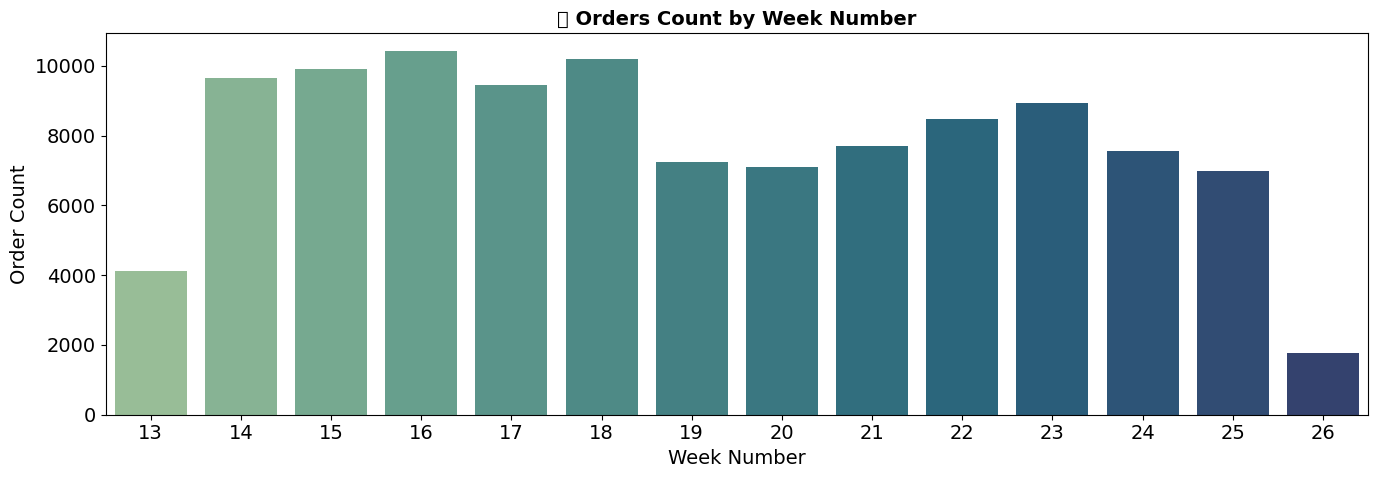

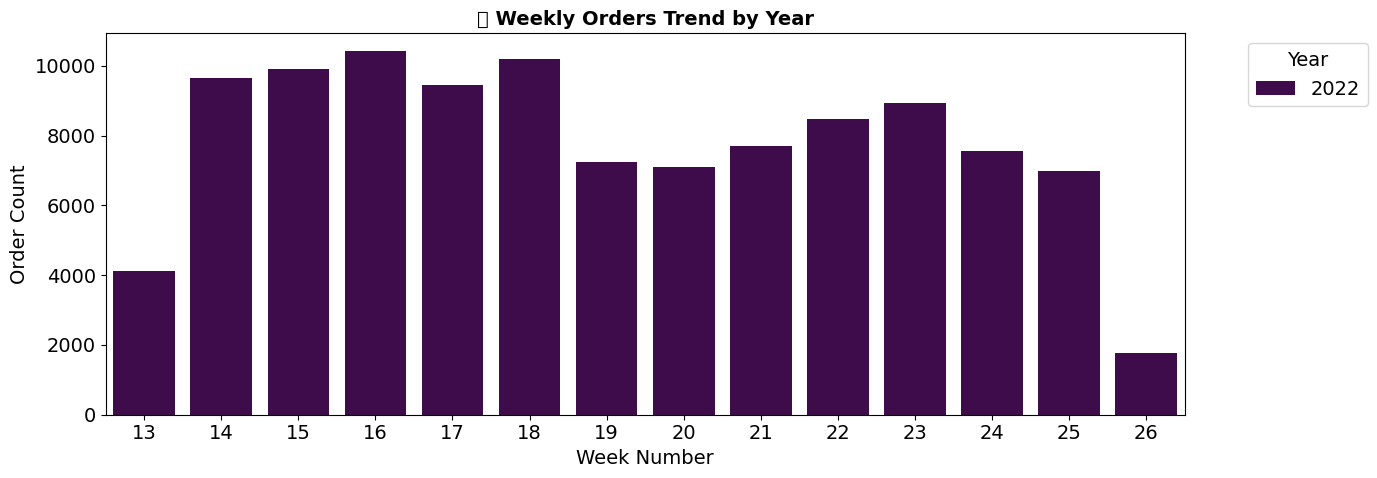

📊 Week-over-Week Growth Summary:

 Year  Week_Number  Order_Count  MoM_Growth_%
 2022           13         4129           NaN
 2022           14         9657    133.882296
 2022           15         9915      2.671637
 2022           16        10409      4.982350
 2022           17         9455     -9.165146
 2022           18        10184      7.710206
 2022           19         7236    -28.947368
 2022           20         7113     -1.699834
 2022           21         7695      8.182202
 2022           22         8478     10.175439
 2022           23         8942      5.472989
 2022           24         7544    -15.634086
 2022           25         6977     -7.515907
 2022           26         1764    -74.716927

🏆 Top Performing Week: Week 16 of 2022 with 10409 orders.


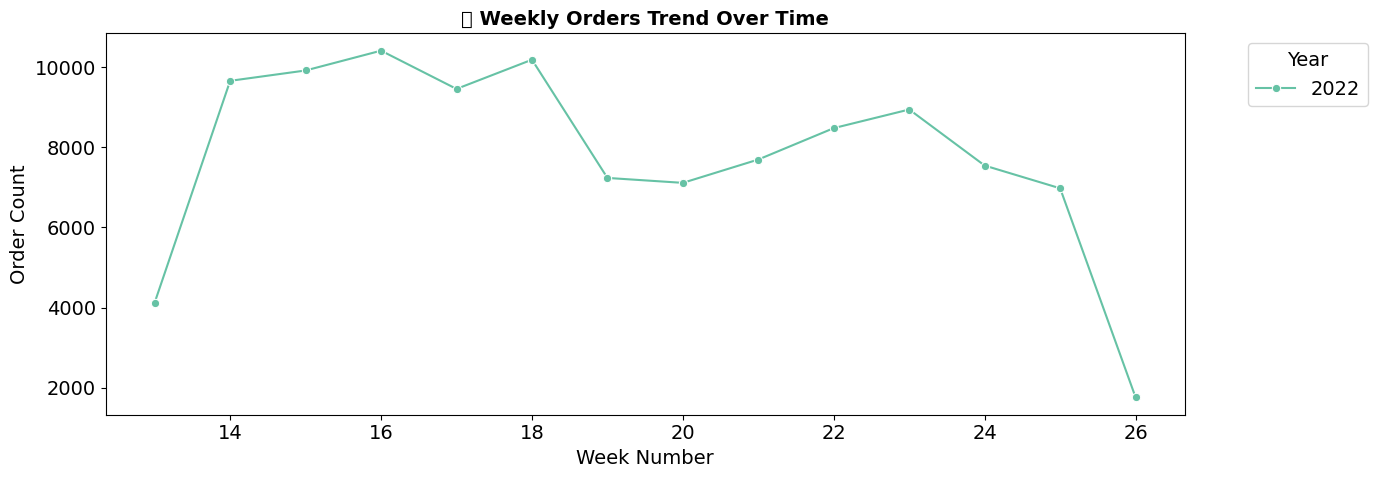

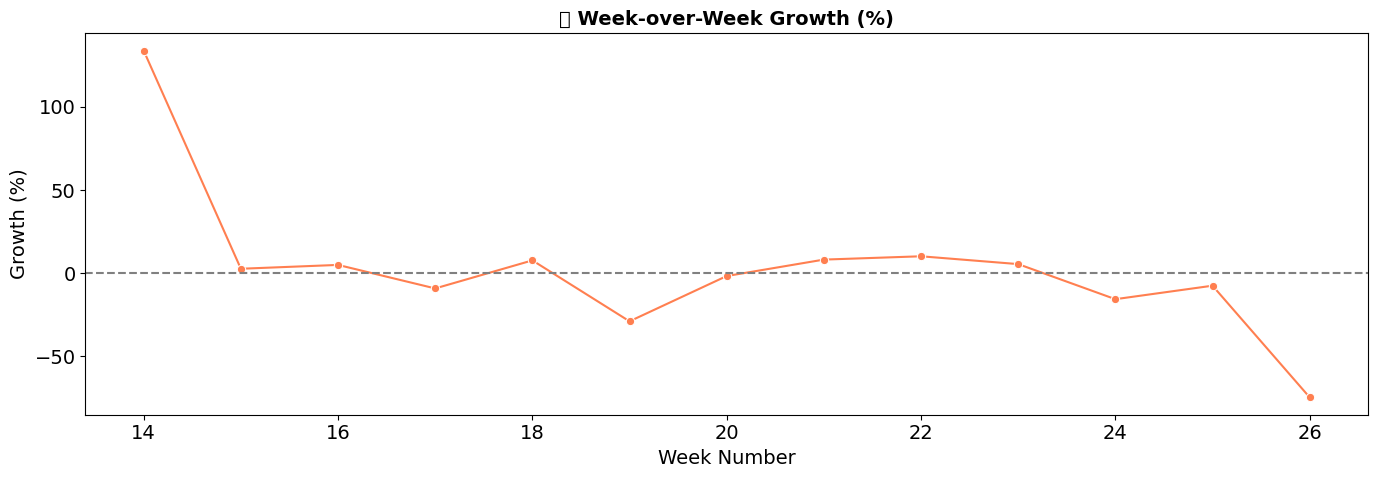


✅ Week-wise analysis completed successfully!


In [ ]:
week_df = shipped_df.copy()
weekwise_analysis(week_df)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def weekly_sales_by_category(df, date_col='Date', amount_col='Amount', category_col='Category'):
    """
    Analyze and visualize total weekly sales grouped by each category.

    Parameters:
        df (DataFrame): The input dataset
        date_col (str): Column name for date
        amount_col (str): Column name for sales amount
        category_col (str): Column name for category
    """

    # Convert date column
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

    # Extract week and year
    df['Year'] = df[date_col].dt.year
    df['Week_Number'] = df[date_col].dt.isocalendar().week

    # Group by week, year, and category
    weekly_sales = (
        df.groupby(['Year', 'Week_Number', category_col])[amount_col]
        .sum()
        .reset_index()
        .sort_values(['Year', 'Week_Number'])
    )

    print("✅ Weekly total sales grouped by category computed successfully!\n")
    print(weekly_sales)

    # Identify top-performing week and category
    top_entry = weekly_sales.loc[weekly_sales[amount_col].idxmax()]
    print(f"\n🏆 Top Performing Week: Week {top_entry['Week_Number']} ({int(top_entry['Year'])}) "
          f"in Category '{top_entry[category_col]}' with total sales of ₹{top_entry[amount_col]:,.2f}")

    # 📈 Plot 1: Weekly Total Sales per Category
    plt.figure(figsize=(14, 6))
    sns.lineplot(
        data=weekly_sales,
        x='Week_Number',
        y=amount_col,
        hue=category_col,
        style='Year',
        markers=True,
        dashes=False,
        palette='tab10'
    )
    plt.title('📊 Weekly Total Sales by Category', fontsize=14, weight='bold')
    plt.xlabel('Week Number')
    plt.ylabel('Total Sales (₹)')
    plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # 📦 Plot 2: Heatmap for Visual Category Comparison
    plt.figure(figsize=(12, 6))
    pivot_table = weekly_sales.pivot_table(
        values=amount_col,
        index='Week_Number',
        columns=category_col,
        aggfunc='sum',
        fill_value=0
    )
    sns.heatmap(pivot_table, cmap='YlGnBu', linewidths=0.5)
    plt.title('🔥 Weekly Sales Heatmap by Category', fontsize=14, weight='bold')
    plt.xlabel('Category')
    plt.ylabel('Week Number')
    plt.tight_layout()
    plt.show()

    print("\n✅ Weekly sales by category visualization completed!")

    return weekly_sales


✅ Weekly total sales grouped by category computed successfully!

     Year  Week_Number       Category        Amount
0    2022           13         Blouse    181.308975
1    2022           13         Bottom     29.578717
2    2022           13   Ethnic Dress    128.368420
3    2022           13          Saree     45.865067
4    2022           13            Set  11848.565035
5    2022           13            Top   2389.666368
6    2022           13  Western Dress   1716.209170
7    2022           13          kurta   9503.663524
8    2022           14         Blouse    443.897761
9    2022           14         Bottom    237.242299
10   2022           14   Ethnic Dress    474.864207
11   2022           14          Saree     66.285110
12   2022           14            Set  25921.683255
13   2022           14            Top   5057.152610
14   2022           14  Western Dress   6018.406919
15   2022           14          kurta  22410.055596
16   2022           15         Blouse    529.947809

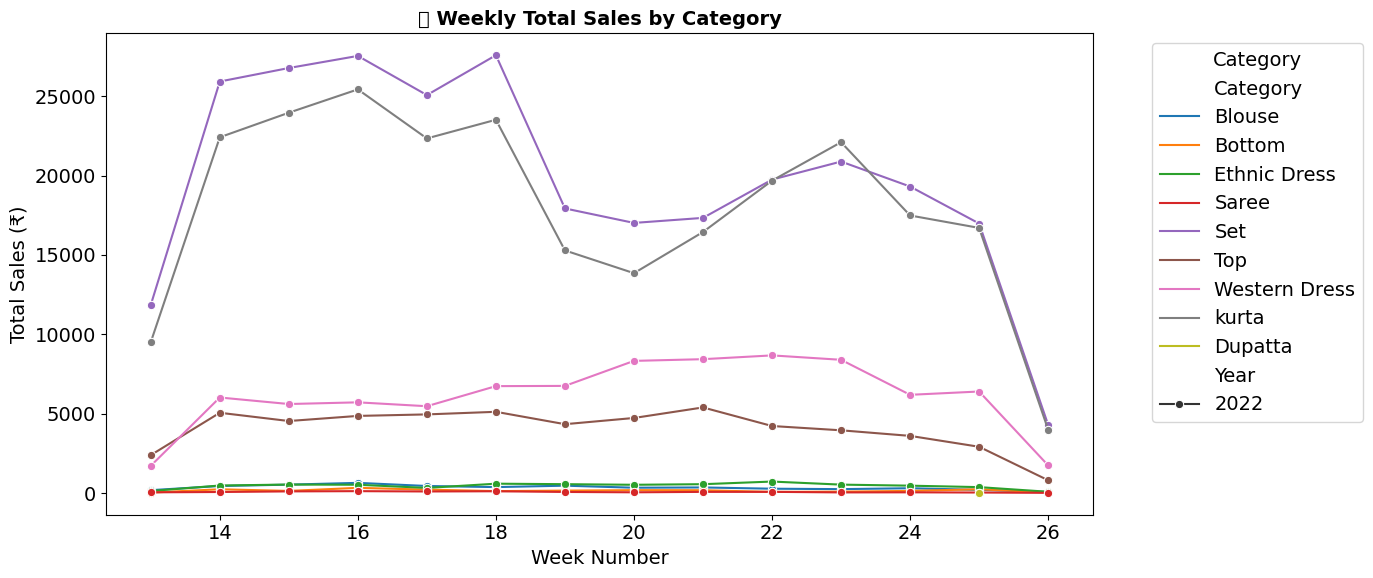

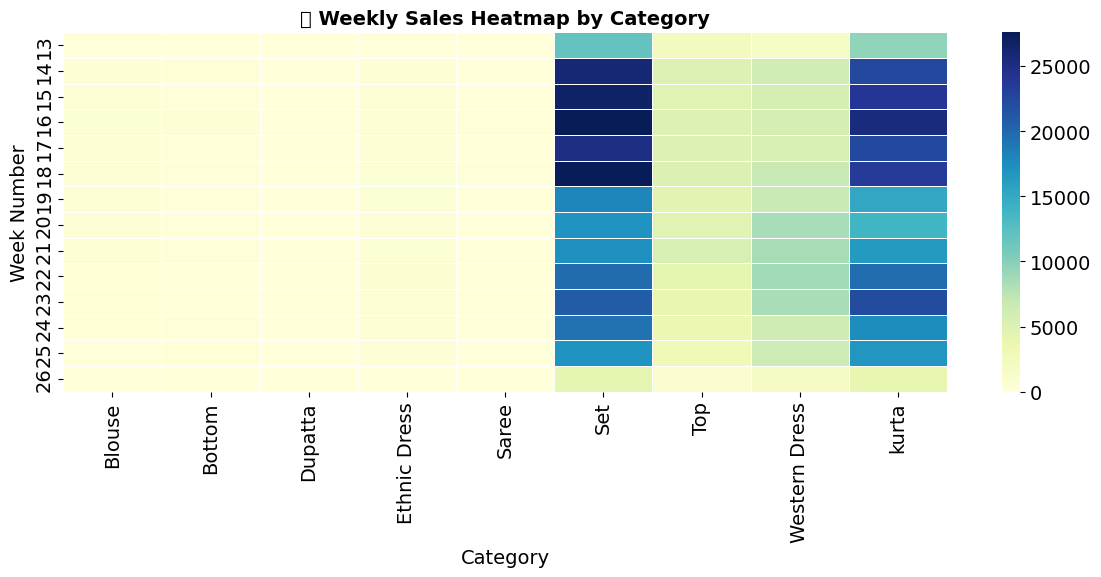


✅ Weekly sales by category visualization completed!


,Year,Week_Number,Category,Amount
0,2022,13,Blouse,181.308975
1,2022,13,Bottom,29.578717
2,2022,13,Ethnic Dress,128.368420
3,2022,13,Saree,45.865067
4,2022,13,Set,11848.565035
5,2022,13,Top,2389.666368
6,2022,13,Western Dress,1716.209170
7,2022,13,kurta,9503.663524
8,2022,14,Blouse,443.897761
9,2022,14,Bottom,237.242299


In [ ]:
week_sale_df = shipped_df.copy()
weekly_sales_by_category(week_sale_df)

In [ ]:
sdf = week_df.sort_values('Date')

In [ ]:
sdf.columns

Index(['Date', 'Status', 'Fulfilment', 'Sales Channel ', 'ship-service-level',
       'Style', 'SKU', 'Category', 'Size', 'ASIN', 'Courier Status', 'Qty',
       'currency', 'Amount', 'ship-state', 'promotion-ids', 'B2B', 'Month',
       'Week_Number', 'Year', 'Month_Name'],
      dtype='object')

In [ ]:
sdf['Courier Status'].value_counts()

Courier Status
Shipped    109498
Name: count, dtype: int64

In [ ]:
# Create lag and lead variables
sdf['Amount_Lead1'] = sdf['Amount'].shift(-1)
sdf['Amount_Lead2'] = sdf['Amount'].shift(-2)
sdf['Amount_Lead3'] = sdf['Amount'].shift(-3)
sdf['Amount_Lead4'] = sdf['Amount'].shift(-4)

In [ ]:
for lag in range(1, 5):
    sdf[f'Amount_Lag{lag}'] = sdf['Amount'].shift(lag)
    corr = sdf[['Amount', f'Amount_Lag{lag}']].corr().iloc[0, 1]
    print(f"Lag {lag} correlation: {corr:.3f}")


Lag 1 correlation: 0.013
Lag 2 correlation: 0.014
Lag 3 correlation: 0.009
Lag 4 correlation: 0.007


In [ ]:
sdf.columns

Index(['Date', 'Status', 'Fulfilment', 'Sales Channel ', 'ship-service-level',
       'Style', 'SKU', 'Category', 'Size', 'ASIN', 'Courier Status', 'Qty',
       'currency', 'Amount', 'ship-state', 'promotion-ids', 'B2B', 'Month',
       'Week_Number', 'Year', 'Month_Name', 'Amount_Lead1', 'Amount_Lead2',
       'Amount_Lead3', 'Amount_Lead4', 'Amount_Lag1', 'Amount_Lag2',
       'Amount_Lag3', 'Amount_Lag4'],
      dtype='object')

In [ ]:
num = sdf.select_dtypes(include=np.number).columns.to_list()

sdf[num].corr()

,Qty,Amount,Week_Number,Year,Amount_Lead1,Amount_Lead2,Amount_Lead3,Amount_Lead4,Amount_Lag1,Amount_Lag2,Amount_Lag3,Amount_Lag4
Qty,1.000000,0.060290,-0.002131,NaN,0.000644,-0.000549,0.007863,0.002752,0.001789,0.001047,-0.001085,-0.002012
Amount,0.060290,1.000000,0.012876,NaN,0.012709,0.014173,0.008684,0.007239,0.012709,0.014173,0.008684,0.007239
Week_Number,-0.002131,0.012876,1.000000,NaN,0.012862,0.012863,0.012869,0.012866,0.012878,0.012876,0.012876,0.012842
Year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amount_Lead1,0.000644,0.012709,0.012862,NaN,1.000000,0.012710,0.014171,0.008686,0.014173,0.008684,0.007239,0.003425
Amount_Lead2,-0.000549,0.014173,0.012863,NaN,0.012710,1.000000,0.012711,0.014171,0.008684,0.007239,0.003425,0.003874
Amount_Lead3,0.007863,0.008684,0.012869,NaN,0.014171,0.012711,1.000000,0.012712,0.007239,0.003425,0.003874,0.010183
Amount_Lead4,0.002752,0.007239,0.012866,NaN,0.008686,0.014171,0.012712,1.000000,0.003425,0.003874,0.010183,0.007803
Amount_Lag1,0.001789,0.012709,0.012878,NaN,0.014173,0.008684,0.007239,0.003425,1.000000,0.012708,0.014173,0.008683
Amount_Lag2,0.001047,0.014173,0.012876,NaN,0.008684,0.007239,0.003425,0.003874,0.012708,1.000000,0.012706,0.014170


In [ ]:
lead_lags = ['Amount_Lead1', 'Amount_Lead2','Amount_Lead3', 'Amount_Lead4', 'Amount_Lag1', 'Amount_Lag2','Amount_Lag3', 'Amount_Lag4']

sdf[lead_lags].corr()

,Amount_Lead1,Amount_Lead2,Amount_Lead3,Amount_Lead4,Amount_Lag1,Amount_Lag2,Amount_Lag3,Amount_Lag4
Amount_Lead1,1.000000,0.012710,0.014171,0.008686,0.014173,0.008684,0.007239,0.003425
Amount_Lead2,0.012710,1.000000,0.012711,0.014171,0.008684,0.007239,0.003425,0.003874
Amount_Lead3,0.014171,0.012711,1.000000,0.012712,0.007239,0.003425,0.003874,0.010183
Amount_Lead4,0.008686,0.014171,0.012712,1.000000,0.003425,0.003874,0.010183,0.007803
Amount_Lag1,0.014173,0.008684,0.007239,0.003425,1.000000,0.012708,0.014173,0.008683
Amount_Lag2,0.008684,0.007239,0.003425,0.003874,0.012708,1.000000,0.012706,0.014170
Amount_Lag3,0.007239,0.003425,0.003874,0.010183,0.014173,0.012706,1.000000,0.012705
Amount_Lag4,0.003425,0.003874,0.010183,0.007803,0.008683,0.014170,0.012705,1.000000


In [ ]:
lead_lags = sdf[['Amount_Lead1', 'Amount_Lead2','Amount_Lead3', 'Amount_Lead4', 'Amount_Lag1', 'Amount_Lag2','Amount_Lag3', 'Amount_Lag4']]

lead_lags.isnull().sum()

Amount_Lead1    1
Amount_Lead2    2
Amount_Lead3    3
Amount_Lead4    4
Amount_Lag1     1
Amount_Lag2     2
Amount_Lag3     3
Amount_Lag4     4
dtype: int64

In [ ]:
for i in ['Amount_Lead1', 'Amount_Lead2','Amount_Lead3', 'Amount_Lead4', 'Amount_Lag1', 'Amount_Lag2','Amount_Lag3', 'Amount_Lag4']:

    sdf[i] = sdf[i].fillna(0)

In [ ]:
lead_lags = sdf[['Amount_Lead1', 'Amount_Lead2','Amount_Lead3', 'Amount_Lead4', 'Amount_Lag1', 'Amount_Lag2','Amount_Lag3', 'Amount_Lag4']]

lead_lags.isnull().sum()

Amount_Lead1    0
Amount_Lead2    0
Amount_Lead3    0
Amount_Lead4    0
Amount_Lag1     0
Amount_Lag2     0
Amount_Lag3     0
Amount_Lag4     0
dtype: int64

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

lead_lags = sdf[['Amount_Lead1', 'Amount_Lead2','Amount_Lead3', 'Amount_Lead4', 'Amount_Lag1', 'Amount_Lag2','Amount_Lag3', 'Amount_Lag4']]

X = sm.add_constant(lead_lags)

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

        Feature         VIF
0         const  295.594798
1  Amount_Lead1    1.000764
2  Amount_Lead2    1.000694
3  Amount_Lead3    1.000730
4  Amount_Lead4    1.000654
5   Amount_Lag1    1.000767
6   Amount_Lag2    1.000697
7   Amount_Lag3    1.000734
8   Amount_Lag4    1.000659


In [ ]:
# import pandas as pd
# import numpy as np
# import seaborn as sns
# import matplotlib.pyplot as plt
# from statsmodels.tsa.stattools import acf

# def analyze_lags_and_leads(df, target_col='Amount', time_col='Date', max_lag=6):
#     """
#     Automatically creates lag and lead features, computes correlations,
#     and visualizes top correlated lags for time-series or sales data.
#     """
#     # --- Step 1. Sort and prepare data ---
#     df = df.copy()
#     df[time_col] = pd.to_datetime(df[time_col], errors='coerce')
#     df = df.sort_values(time_col).reset_index(drop=True)

#     # --- Step 2. Create lag and lead columns ---
#     for i in range(1, max_lag + 1):
#         df[f'{target_col}_Lag{i}'] = df[target_col].shift(i)
#         df[f'{target_col}_Lead{i}'] = df[target_col].shift(-i)

#     print(f"✅ Created lag and lead features for {target_col} (1 to {max_lag})")

#     # --- Step 3. Compute correlations ---
#     correlations = {}
#     for i in range(1, max_lag + 1):
#         lag_corr = df[[target_col, f'{target_col}_Lag{i}']].corr().iloc[0, 1]
#         lead_corr = df[[target_col, f'{target_col}_Lead{i}']].corr().iloc[0, 1]
#         correlations[f'Lag{i}'] = lag_corr
#         correlations[f'Lead{i}'] = lead_corr

#     corr_df = pd.DataFrame.from_dict(correlations, orient='index', columns=['Correlation']).sort_values('Correlation', ascending=False)
#     print("\n📊 Correlations with Lag/Lead variables:")
#     print(corr_df.round(3))

#     # --- Step 4. Top correlated lags/leads ---
#     top_corr = corr_df.head(3)
#     print("\n🏆 Top 3 Most Significant Temporal Features:")
#     print(top_corr)

#     # --- Step 5. Visualizations ---
#     plt.figure(figsize=(10, 4))
#     sns.barplot(x=corr_df.index, y='Correlation', data=corr_df, palette='Spectral')
#     plt.title(f'🔁 Correlation of {target_col} with Lags and Leads', fontsize=14)
#     plt.xticks(rotation=45)
#     plt.axhline(0, color='gray', linestyle='--')
#     plt.tight_layout()
#     plt.show()

#     # Plot autocorrelation (ACF)
#     plt.figure(figsize=(8, 4))
#     sns.lineplot(x=range(len(acf(df[target_col].dropna(), nlags=max_lag))),
#                  y=acf(df[target_col].dropna(), nlags=max_lag),
#                  marker='o', color='teal')
#     plt.title(f'📈 Autocorrelation of {target_col} up to {max_lag} lags')
#     plt.xlabel('Lag')
#     plt.ylabel('ACF')
#     plt.axhline(0, color='gray', linestyle='--')
#     plt.show()

#     # Plot top lag vs target (scatter)
#     for lag_label in top_corr.index:
#         col = f"{target_col}_{lag_label}"
#         plt.figure(figsize=(6, 4))
#         sns.regplot(x=col, y=target_col, data=df, scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
#         plt.title(f"📊 {target_col} vs {col}")
#         plt.show()

#     return df, corr_df


In [ ]:
# df_with_lags, lag_summary = analyze_lags_and_leads(sdf, target_col='Amount', time_col='Date', max_lag=6)

In [ ]:
pt_table = pd.pivot_table(
        data=shipped_df,
        values=['Amount'],
        index=['Category'],
        columns=['Week_Number'],
        aggfunc='sum',
        fill_value=0
    )

pt_table

Amount                                            \
Week_Number              13            14            15            16   
Category                                                                
Blouse           181.308975    443.897761    529.947809    641.537386   
Bottom            29.578717    237.242299    134.568842    327.629663   
Dupatta            0.000000      0.000000      0.000000      0.000000   
Ethnic Dress     128.368420    474.864207    535.501074    522.650763   
Saree             45.865067     66.285110    104.737091    119.857561   
Set            11848.565035  25921.683255  26772.078558  27534.177138   
Top             2389.666368   5057.152610   4537.001336   4858.511536   
Western Dress   1716.209170   6018.406919   5607.339771   5713.790985   
kurta           9503.663524  22410.055596  23956.636938  25425.932215   

                                                                       \
Week_Number              17            18            19            20   
Category                                                                
Blouse           444.903682    375.453932    464.603439    336.224983   
Bottom           215.081366    122.490289    153.616553    181.655624   
Dupatta            0.000000      0.000000      0.000000      0.000000   
Ethnic Dress     323.294859    589.724399    559.050558    521.144397   
Saree             99.536049    112.731855     69.015978     47.018789   
Set            25066.808927  27578.316866  17927.034727  17014.984008   
Top             4954.138896   5117.323564   4337.479245   4729.123237   
Western Dress   5469.452503   6734.491670   6749.322062   8324.941142   
kurta          22336.671059  23512.586560  15281.808877  13848.751909   

                                                                       \
Week_Number              21            22            23            24   
Category                                                                
Blouse           352.748322    273.394190    246.986698    304.240121   
Bottom           177.801052     71.558880     87.855533    134.860384   
Dupatta            0.000000      0.000000      0.000000      0.000000   
Ethnic Dress     558.292429    723.850358    531.102533    464.830345   
Saree             73.869772     75.397483     40.403760     46.283460   
Set            17332.060567  19743.691570  20880.487257  19307.167581   
Top             5392.784861   4222.470963   3952.393505   3600.896886   
Western Dress   8432.160326   8670.411818   8393.338428   6187.859343   
kurta          16442.568432  19677.653600  22098.385468  17483.631443   

                                          
Week_Number              25           26  
Category                                  
Blouse           199.723789    70.751801  
Bottom           238.124306    36.088669  
Dupatta           17.170755     0.000000  
Ethnic Dress     373.292338    80.532995  
Saree             33.072626    13.306683  
Set            16977.266094  4293.962834  
Top             2915.264724   805.189301  
Western Dress   6395.658705  1741.798444  
kurta          16700.867104  3991.602385

In [ ]:
weekly_sales = (
    shipped_df
    .groupby(['Category', 'Week_Number'])['Amount']
    .sum()
    .reset_index()
    .sort_values(['Category', 'Week_Number'])
)

display(weekly_sales.head())


,Category,Week_Number,Amount
0,Blouse,13,181.308975
1,Blouse,14,443.897761
2,Blouse,15,529.947809
3,Blouse,16,641.537386
4,Blouse,17,444.903682


In [ ]:
# Step 1: Compute total sales per SKU
sku_sales = shipped_df.groupby(['Category','SKU'])['Amount'].sum().reset_index()

# Step 2: Merge with your weekly_sales dataframe
weekly_sale = (
    shipped_df
    .groupby(['Category', 'Week_Number'])['Amount']
    .sum()
    .reset_index()
    .merge(sku_sales, on='Category', how='left', suffixes=('', '_TotalSKU'))
    .sort_values(['Amount_TotalSKU', 'Category', 'Week_Number'], ascending=[False, True, True])
)

display(weekly_sale.head())


,Category,Week_Number,Amount,SKU,Amount_TotalSKU
52956,Western Dress,13,1716.209170,JNE3797-KR-L,4060.999559
53409,Western Dress,14,6018.406919,JNE3797-KR-L,4060.999559
53862,Western Dress,15,5607.339771,JNE3797-KR-L,4060.999559
54315,Western Dress,16,5713.790985,JNE3797-KR-L,4060.999559
54768,Western Dress,17,5469.452503,JNE3797-KR-L,4060.999559


In [ ]:
weekly_sale.columns

Index(['Category', 'Week_Number', 'Amount', 'SKU', 'Amount_TotalSKU'], dtype='object')

In [ ]:
weekly_sale.dtypes

Category            object
Week_Number         UInt32
Amount             float64
SKU                 object
Amount_TotalSKU    float64
dtype: object

In [ ]:
from sklearn.preprocessing import LabelEncoder
import statsmodels.api as sm

In [ ]:
lab = LabelEncoder()

In [ ]:
main_df = weekly_sale.copy()

In [ ]:
main_df['Week_Number'] = main_df['Week_Number'].astype(int)

In [ ]:
cat = main_df.select_dtypes(include=object).columns.to_list()

for i in cat:
    main_df[i] = lab.fit_transform(main_df[[i]])

In [ ]:
num = main_df.select_dtypes(include=np.number).columns.to_list()

for i in num:
    main_df[i] = np.log1p(main_df[i])

In [ ]:
main_df.dtypes

Category           float64
Week_Number        float64
Amount             float64
SKU                float64
Amount_TotalSKU    float64
dtype: object

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x = main_df.drop('Amount_TotalSKU', axis=1)
y = main_df['Amount_TotalSKU']

In [ ]:
x.dtypes

Category       float64
Week_Number    float64
Amount         float64
SKU            float64
dtype: object

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=10)

In [ ]:
x_train_c = sm.add_constant(x_train)
x_test_c = sm.add_constant(x_test)

In [ ]:
ols_model = sm.OLS(y_train, x_train_c).fit()
ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        Amount_TotalSKU   R-squared:                       0.058
Model:                            OLS   Adj. R-squared:                  0.058
Method:                 Least Squares   F-statistic:                     1076.
Date:                Mon, 10 Nov 2025   Prob (F-statistic):               0.00
Time:                        15:11:13   Log-Likelihood:            -1.1126e+05
No. Observations:               69552   AIC:                         2.225e+05
Df Residuals:                   69547   BIC:                         2.226e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.9559      0.081     11.827      0.000       0.797       1.114
Category       -0.0442      0.016     -2.845      0.004      -0.075      -0.014
Week_Number     0.0936      0.023      4.107      0.000       0.049       0.138
Amount          0.1263      0.005     26.531      0.000       0.117       0.136
SKU             0.1844      0.006     32.298      0.000       0.173       0.196
==============================================================================
Omnibus:                     1130.674   Durbin-Watson:                   2.009
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1186.016
Skew:                           0.319   Prob(JB):                    2.88e-258
Kurtosis:                       2.960   Cond. No.                         234.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
summary = pd.DataFrame(columns=['Model Name', 'R2 Score', 'MAE', 'MSE', 'RMSE'])

def score_card(model_name, model, x_train, x_test, y_train, y_test):
    global summary

    model = model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    r_2_score = round( r2_score(y_test, y_pred) ,3)
    mae = round( mean_absolute_error(y_test, y_pred) ,3)
    mse = round( mean_squared_error(y_test, y_pred) ,3)
    rmse = round( np.sqrt(mse) ,3)

    new_score = pd.DataFrame({
        'Model Name': [model_name],
        'R2 Score': [r_2_score],
        'MAE': [mae],
        'MSE': [mse],
        'RMSE': [rmse]
    })

    summary = pd.concat([summary, new_score], ignore_index=True)

    return summary

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

In [ ]:
lr = LinearRegression()
rid = Ridge(random_state=10)
lasso = Lasso(random_state=10)
enet = ElasticNet(random_state=10)

In [ ]:
score_card('Linear Regression', lr, x_train, x_test, y_train, y_test)
score_card('Ridge', rid, x_train, x_test, y_train, y_test)
score_card('Lasso', lasso, x_train, x_test, y_train, y_test)
score_card('Elastic Net', enet, x_train, x_test, y_train, y_test)

,Model Name,R2 Score,MAE,MSE,RMSE
0,Linear Regression,0.057,0.970,1.437,1.199
1,Ridge,0.057,0.970,1.437,1.199
2,Lasso,-0.000,1.012,1.525,1.235
3,Elastic Net,-0.000,1.012,1.525,1.235


In [ ]:
from sklearn.tree import DecisionTreeRegressor

In [ ]:
dt = DecisionTreeRegressor(random_state=10)

In [ ]:
score_card('Decision Tree', dt, x_train, x_test, y_train, y_test)

,Model Name,R2 Score,MAE,MSE,RMSE
0,Linear Regression,0.057,0.970,1.437,1.199
1,Ridge,0.057,0.970,1.437,1.199
2,Lasso,-0.000,1.012,1.525,1.235
3,Elastic Net,-0.000,1.012,1.525,1.235
4,Decision Tree,0.999,0.001,0.002,0.045


In [ ]:
sdf.dtypes

Date                  datetime64[ns]
Status                        object
Fulfilment                    object
Sales Channel                 object
ship-service-level            object
Style                         object
SKU                           object
Category                      object
Size                          object
ASIN                          object
Courier Status                object
Qty                          float64
currency                      object
Amount                       float64
ship-state                    object
promotion-ids                 object
B2B                             bool
Month                         object
Week_Number                   UInt32
Year                           int32
Month_Name                    object
Amount_Lead1                 float64
Amount_Lead2                 float64
Amount_Lead3                 float64
Amount_Lead4                 float64
Amount_Lag1                  float64
Amount_Lag2                  float64
A

In [ ]:
sdf['Week_Number'] = sdf['Week_Number'].astype(int)

In [ ]:
cat = sdf.select_dtypes(include=object).columns.to_list()

for i in cat:
    sdf[i] = lab.fit_transform(sdf[[i]])

In [ ]:
sdf.drop('Date', axis=1, inplace=True)

In [ ]:
sdf.drop('B2B', axis=1, inplace=True)

In [ ]:
num = sdf.select_dtypes(include=np.number).columns.to_list()

for i in num:
    sdf[i] = np.log1p(sdf[i])

In [ ]:
x1 = sdf.drop('Amount', axis=1)
y1 = sdf['Amount']

In [ ]:
x1_train, x1_test, y1_train, y1_test = train_test_split(x1, y1, test_size=0.3, random_state=10)

In [ ]:
x1_train_c = sm.add_constant(x1_train)
x1_test_c = sm.add_constant(x1_test)

In [ ]:
ols1_model = sm.OLS(y1_train, x1_train_c).fit()
ols1_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Amount   R-squared:                       0.343
Model:                            OLS   Adj. R-squared:                  0.342
Method:                 Least Squares   F-statistic:                     1902.
Date:                Mon, 10 Nov 2025   Prob (F-statistic):               0.00
Time:                        15:11:18   Log-Likelihood:                 1704.4
No. Observations:               76648   AIC:                            -3365.
Df Residuals:                   76626   BIC:                            -3161.
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Status                -0.0052      0.007     -0.726      0.468      -0.019       0.009
Fulfilment             2.5357      0.017    151.491      0.000       2.503       2.569
Sales Channel      -2.053e-16   4.36e-17     -4.712      0.000   -2.91e-16    -1.2e-16
ship-service-level    -2.6560      0.014   -192.884      0.000      -2.683      -2.629
Style                  0.1374      0.021      6.568      0.000       0.096       0.178
SKU                   -0.1184      0.018     -6.582      0.000      -0.154      -0.083
Category              -0.0422      0.004    -10.328      0.000      -0.050      -0.034
Size                  -0.0067      0.001     -5.485      0.000      -0.009      -0.004
ASIN                   0.0160      0.001     15.591      0.000       0.014       0.018
Courier Status      -7.88e-16   5.74e-17    -13.723      0.000   -9.01e-16   -6.75e-16
Qty                    0.8672      0.059     14.696      0.000       0.752       0.983
currency           -7.197e-16   7.29e-17     -9.875      0.000   -8.63e-16   -5.77e-16
ship-state            -0.0018      0.001     -1.423      0.155      -0.004       0.001
promotion-ids         -0.1093      0.005    -20.919      0.000      -0.120      -0.099
Month                  0.0021      0.001      2.393      0.017       0.000       0.004
Week_Number           -0.0069      0.006     -1.233      0.218      -0.018       0.004
Year                   0.2120      0.005     39.447      0.000       0.202       0.223
Month_Name             0.0021      0.001      2.393      0.017       0.000       0.004
Amount_Lead1           0.0025      0.003      0.858      0.391      -0.003       0.008
Amount_Lead2           0.0134      0.003      4.594      0.000       0.008       0.019
Amount_Lead3           0.0026      0.003      0.904      0.366      -0.003       0.008
Amount_Lead4           0.0069      0.003      2.361      0.018       0.001       0.013
Amount_Lag1            0.0044      0.003      1.480      0.139      -0.001       0.010
Amount_Lag2            0.0104      0.003      3.558      0.000       0.005       0.016
Amount_Lag3            0.0034      0.003      1.158      0.247      -0.002       0.009
Amount_Lag4            0.0087      0.003      2.991      0.003       0.003       0.014
==============================================================================
Omnibus:                    97243.978   Durbin-Watson:                   2.007
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         12555508.190
Skew:                          -7.232   Prob(JB):                         0.00
Kurtosis:                      64.009   Cond. No.                     1.08e+16
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correct

In [ ]:
sdf.columns

Index(['Status', 'Fulfilment', 'Sales Channel ', 'ship-service-level', 'Style',
       'SKU', 'Category', 'Size', 'ASIN', 'Courier Status', 'Qty', 'currency',
       'Amount', 'ship-state', 'promotion-ids', 'Month', 'Week_Number', 'Year',
       'Month_Name', 'Amount_Lead1', 'Amount_Lead2', 'Amount_Lead3',
       'Amount_Lead4', 'Amount_Lag1', 'Amount_Lag2', 'Amount_Lag3',
       'Amount_Lag4'],
      dtype='object')

In [ ]:
x2 = sdf[['Amount_Lag1','Amount_Lag2','Amount_Lag3','Amount_Lag4']]
y2 = sdf['Amount']

In [ ]:
x2_train, x2_test, y2_train, y2_test = train_test_split(x2, y2, test_size=0.3, random_state=10)

In [ ]:
x2_train_c = sm.add_constant(x2_train)
x2_test_c = sm.add_constant(x2_test)

In [ ]:
ols2 = sm.OLS(y2_train, x2_train_c).fit()
ols2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Amount   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     8.723
Date:                Mon, 10 Nov 2025   Prob (F-statistic):           4.90e-07
Time:                        15:16:40   Log-Likelihood:                -14354.
No. Observations:               76648   AIC:                         2.872e+04
Df Residuals:                   76643   BIC:                         2.876e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           1.8823      0.014    134.728      0.000       1.855       1.910
Amount_Lag1     0.0088      0.004      2.400      0.016       0.002       0.016
Amount_Lag2     0.0149      0.004      4.128      0.000       0.008       0.022
Amount_Lag3     0.0066      0.004      1.820      0.069      -0.001       0.014
Amount_Lag4     0.0100      0.004      2.773      0.006       0.003       0.017
==============================================================================
Omnibus:                    88093.973   Durbin-Watson:                   2.003
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          5570765.784
Skew:                          -6.351   Prob(JB):                         0.00
Kurtosis:                      42.787   Cond. No.                         55.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
X_c = sm.add_constant(x1.select_dtypes(include=['number']))  # numeric only
ols_model = sm.OLS(y1, X_c).fit()
ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Amount   R-squared:                       0.342
Model:                            OLS   Adj. R-squared:                  0.342
Method:                 Least Squares   F-statistic:                     2713.
Date:                Mon, 10 Nov 2025   Prob (F-statistic):               0.00
Time:                        15:28:11   Log-Likelihood:                 1790.4
No. Observations:              109498   AIC:                            -3537.
Df Residuals:                  109476   BIC:                            -3326.
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Status                -0.0012      0.006     -0.202      0.840      -0.013       0.011
Fulfilment             2.5245      0.014    179.585      0.000       2.497       2.552
Sales Channel       1.169e-15   6.85e-17     17.066      0.000    1.03e-15     1.3e-15
ship-service-level    -2.6534      0.012   -230.396      0.000      -2.676      -2.631
Style                  0.1084      0.018      6.172      0.000       0.074       0.143
SKU                   -0.0935      0.015     -6.197      0.000      -0.123      -0.064
Category              -0.0435      0.003    -12.723      0.000      -0.050      -0.037
Size                  -0.0055      0.001     -5.356      0.000      -0.007      -0.003
ASIN                   0.0156      0.001     18.122      0.000       0.014       0.017
Courier Status     -4.191e-15   8.99e-17    -46.599      0.000   -4.37e-15   -4.01e-15
Qty                    0.8941      0.049     18.097      0.000       0.797       0.991
currency             1.68e-15   4.85e-17     34.624      0.000    1.59e-15    1.78e-15
ship-state            -0.0006      0.001     -0.600      0.548      -0.003       0.001
promotion-ids         -0.1115      0.004    -25.176      0.000      -0.120      -0.103
Month                  0.0017      0.001      2.238      0.025       0.000       0.003
Week_Number           -0.0079      0.005     -1.680      0.093      -0.017       0.001
Year                   0.2097      0.005     46.434      0.000       0.201       0.219
Month_Name             0.0017      0.001      2.238      0.025       0.000       0.003
Amount_Lead1           0.0068      0.002      2.785      0.005       0.002       0.012
Amount_Lead2           0.0104      0.002      4.224      0.000       0.006       0.015
Amount_Lead3           0.0036      0.002      1.477      0.140      -0.001       0.008
Amount_Lead4           0.0068      0.002      2.764      0.006       0.002       0.012
Amount_Lag1            0.0040      0.002      1.618      0.106      -0.001       0.009
Amount_Lag2            0.0092      0.002      3.743      0.000       0.004       0.014
Amount_Lag3            0.0041      0.002      1.658      0.097      -0.001       0.009
Amount_Lag4            0.0056      0.002      2.268      0.023       0.001       0.010
==============================================================================
Omnibus:                   138347.463   Durbin-Watson:                   2.013
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         17498100.033
Skew:                          -7.188   Prob(JB):                         0.00
Kurtosis:                      63.238   Cond. No.                     1.08e+16
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correct